# Clasificación de Lesiones Dermatoscópicas PH2 — Versión Corregida y Extendida

Este notebook corrige todos los problemas detectados en la versión anterior y agrega
nuevos experimentos.

## Correcciones aplicadas

| # | Problema original | Corrección |
|---|---|---|
| 1 | EfficientNetB0 con `image/255` | Pipeline de preprocesamiento por arquitectura usando `preprocess_input` nativo |
| 2 | Sin test set independiente | Split estratificado 60/20/20 (train/val/test) — test solo se toca al final |
| 3 | Loss inflado por L2 | Se loggea `categorical_crossentropy` puro como métrica separada |
| 4 | Two-stage fine-tuning mal hecho | Fase 1 (head solo) → Fase 2 (descongelar con LR bajo) |
| 5 | Solo accuracy/F1 | Se agregan AUC-ROC, AUC-PR, Sensibilidad, Especificidad, Balanced Accuracy |
| 6 | `class_weight` insuficiente | Implementación opcional de Focal Loss |
| 7 | Sin uso de máscaras de PH2 | Pipeline alternativo con recorte por máscara de lesión |
| 8 | Sin Grad-CAM | Visualización de regiones atendidas para QA clínico |
| 9 | Sin ensemble tabular+imagen | Stacking de probabilidades imagen + features tabulares |
| 10 | Sin CV en imagen | K-fold opcional (3 folds) para los mejores modelos |

## Experimentos

| Bloque | Experimentos |
|---|---|
| **Imagen — Bugs corregidos** | 1. EfficientNetB0 (con preprocess correcto)<br>2. ResNet50 últimas 30 capas<br>3. ResNet50 fine-tuning global<br>4. ResNet50 + Data Augmentation agresivo<br>5. MobileNetV2<br>6. ResNet50 regularizada<br>7. ResNet50 ultra-regularizada (anti-overfitting) |
| **Imagen — Experimentos nuevos** | 8. Two-stage fine-tuning correcto<br>9. Focal Loss (γ=2)<br>10. Mixup<br>11. EfficientNetV2-B0 con preprocess oficial<br>12. ResNet50 + Máscaras de segmentación PH2<br>13. Test-Time Augmentation (TTA)<br>14. Ensemble tabular + imagen<br>15. Calibración + selección de umbral óptimo |


## 1. Setup, imports y configuración

In [1]:
import os
import gc
import random
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    balanced_accuracy_score
)

warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42

def set_reproducibility(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_reproducibility(SEED)

# Configuración global
BASE_PATH = "PH2Dataset"
IMAGES_DIR = os.path.join(BASE_PATH, "PH2 Dataset images")
XLSX_PATH = os.path.join(BASE_PATH, "PH2_dataset.xlsx")
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 3
CLASS_NAMES = ['Common Nevus', 'Atypical Nevus', 'Melanoma']

# Diccionario global para acumular resultados de TODOS los experimentos
RESULTADOS_GLOBALES = []

# Configuración de GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU disponible: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("Advertencia: corriendo en CPU.")


I0000 00:00:1779685959.912158   14172 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU disponible: /physical_device:GPU:0


## 2. Carga del dataset y split estratificado 60/20/20

Cambios respecto a la versión anterior:
- **3-way split estratificado**: train (60%), val (20%) — early stopping/HP tuning,
  test (20%) — solo se evalúa al final, una vez.
- Verificación de paths y conteos por clase.


In [2]:
def cargar_metadata():
    df = pd.read_excel(XLSX_PATH, skiprows=12)
    df.columns = df.columns.str.strip()

    labels, filepaths, ids = [], [], []
    for idx, row in df.iterrows():
        lesion_id = str(row['Image Name']).strip()
        if not lesion_id.startswith('IMD'):
            continue
        img_path = os.path.join(IMAGES_DIR, lesion_id,
                                f"{lesion_id}_Dermoscopic_Image", f"{lesion_id}.bmp")
        if not os.path.exists(img_path):
            continue
        is_common = str(row.get('Common Nevus', '')).strip().upper() == 'X'
        is_atypical = str(row.get('Atypical Nevus', '')).strip().upper() == 'X'
        is_melanoma = str(row.get('Melanoma', '')).strip().upper() == 'X'
        if is_melanoma:
            lab = 2
        elif is_atypical:
            lab = 1
        elif is_common:
            lab = 0
        else:
            continue
        ids.append(lesion_id)
        filepaths.append(img_path)
        labels.append(lab)

    return np.array(ids), np.array(filepaths), np.array(labels), df

ids, filepaths, labels, raw_df = cargar_metadata()
print(f"Muestras válidas: {len(filepaths)}")
for c_idx, c_name in enumerate(CLASS_NAMES):
    print(f"  {c_name}: {np.sum(labels == c_idx)}")


Muestras válidas: 200
  Common Nevus: 80
  Atypical Nevus: 80
  Melanoma: 40


In [3]:
# Split estratificado: 60% train / 20% val / 20% test
ids_dev, ids_test, fp_dev, fp_test, y_dev, y_test = train_test_split(
    ids, filepaths, labels, test_size=0.20, stratify=labels, random_state=SEED
)
ids_train, ids_val, fp_train, fp_val, y_train, y_val = train_test_split(
    ids_dev, fp_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED
)  # 0.25 * 0.80 = 0.20

print(f"Train: {len(fp_train)} — clases {np.bincount(y_train)}")
print(f"Val:   {len(fp_val)} — clases {np.bincount(y_val)}")
print(f"Test:  {len(fp_test)} — clases {np.bincount(y_test)}")


Train: 120 — clases [48 48 24]
Val:   40 — clases [16 16  8]
Test:  40 — clases [16 16  8]


## 3. Pipelines de datos

**Punto clave (corrección de bug):** la función `parse_image` ya NO normaliza a [0,1].
Cada modelo aplicará su propio `preprocess_input` como una `Lambda` en su grafo
(EfficientNet espera [0,255], ResNet50 espera centrado-en-ImageNet, MobileNetV2 espera [-1,1]).

Definimos dos versiones del pipeline:
- **Estándar**: imagen completa redimensionada a 224×224
- **Con máscara**: imagen recortada al bounding box de la lesión usando la máscara de PH2


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def parse_image_raw(filename, label):
    """Lee la imagen BMP y la redimensiona, manteniendo rango [0,255]."""
    img_str = tf.io.read_file(filename)
    img = tf.io.decode_bmp(img_str, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label

def get_mask_path(image_path):
    """Deriva la ruta de la máscara desde la ruta de la imagen."""
    # .../IMDxxx/IMDxxx_Dermoscopic_Image/IMDxxx.bmp -> .../IMDxxx/IMDxxx_lesion/IMDxxx_lesion.bmp
    parts = image_path.split(os.sep)
    lesion_id = parts[-3]
    mask_path = os.path.join(*parts[:-2], f"{lesion_id}_lesion", f"{lesion_id}_lesion.bmp")
    return mask_path

def parse_image_with_mask(filename, label):
    """Recorta la imagen al bounding box de la máscara antes de redimensionar."""
    def _crop_by_mask(img_path):
        img_path_str = img_path.numpy().decode('utf-8')
        mask_path = get_mask_path(img_path_str)

        import cv2
        img = cv2.imread(img_path_str)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            ys, xs = np.where(mask > 127)
            if len(ys) > 0:
                pad = 10
                y0 = max(0, ys.min() - pad)
                y1 = min(img.shape[0], ys.max() + pad)
                x0 = max(0, xs.min() - pad)
                x1 = min(img.shape[1], xs.max() + pad)
                img = img[y0:y1, x0:x1]
        img = cv2.resize(img, IMG_SIZE)
        return img.astype(np.float32)

    img = tf.py_function(_crop_by_mask, [filename], tf.float32)
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    return img, label

# Data augmentation reutilizable
data_augmentation_basic = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(0.2, seed=SEED),
    tf.keras.layers.RandomContrast(0.15, seed=SEED)
], name='aug_basic')

data_augmentation_aggressive = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(factor=1.0, fill_mode="reflect", seed=SEED),
    tf.keras.layers.RandomZoom(height_factor=(-0.1, 0.1),
                                width_factor=(-0.1, 0.1),
                                fill_mode="reflect", seed=SEED),
    tf.keras.layers.RandomBrightness(factor=0.2, value_range=(0.0, 255.0), seed=SEED),
    tf.keras.layers.RandomContrast(factor=0.2, seed=SEED),
], name='aug_aggressive')

def build_dataset(filepaths_arr, labels_arr, parse_fn=parse_image_raw,
                  shuffle=False, augment=None, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((filepaths_arr, labels_arr))
    ds = ds.map(parse_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths_arr), seed=SEED)
    ds = ds.batch(batch_size)
    if augment is not None:
        ds = ds.map(lambda x, y: (augment(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

# Datasets base (sin augment, sin máscara) — pueden usarse para val/test
train_ds = build_dataset(fp_train, y_train, shuffle=True, augment=data_augmentation_basic)
val_ds = build_dataset(fp_val, y_val, shuffle=False, augment=None)
test_ds = build_dataset(fp_test, y_test, shuffle=False, augment=None)

print("[OK] Datasets construidos.")


I0000 00:00:1779685974.563184   14172 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 149 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1


[OK] Datasets construidos.


## 4. Class weights y configuración común

In [5]:
# Class weights desde el set de train para evitar leakage
counts = np.bincount(y_train)
total = len(y_train)
class_weights = {i: total / (NUM_CLASSES * c) for i, c in enumerate(counts)}
print(f"Class weights (calculados sobre train): {class_weights}")

# Ratio Melanoma : No-Melanoma — opcional, peso aún más fuerte para melanoma
class_weights_clinical = {
    0: class_weights[0],
    1: class_weights[1],
    2: class_weights[2] * 1.5  # peso extra a melanoma (FN clínicamente costosos)
}
print(f"Class weights clínicos:                {class_weights_clinical}")


Class weights (calculados sobre train): {0: np.float64(0.8333333333333334), 1: np.float64(0.8333333333333334), 2: np.float64(1.6666666666666667)}
Class weights clínicos:                {0: np.float64(0.8333333333333334), 1: np.float64(0.8333333333333334), 2: np.float64(2.5)}


## 5. Funciones de evaluación, métricas clínicas y registro

Centralizamos la evaluación de cada modelo: AUC-ROC, AUC-PR, Sensibilidad,
Especificidad, F1 Melanoma. Cada experimento llama a `evaluar_y_registrar()`
que actualiza `RESULTADOS_GLOBALES`.


In [6]:
def predecir_en_ds(model, ds):
    """Recorre el dataset y devuelve y_true, y_pred_probs."""
    y_true_l, y_proba_l = [], []
    for imgs, lbls in ds:
        p = model.predict(imgs, verbose=0)
        y_true_l.extend(lbls.numpy())
        y_proba_l.extend(p)
    return np.array(y_true_l), np.array(y_proba_l)

def metricas_completas(y_true, y_proba):
    """Calcula todas las métricas: multiclase y binaria (Melanoma vs resto)."""
    y_pred = np.argmax(y_proba, axis=1)
    y_bin_true = (y_true == 2).astype(int)
    y_bin_pred = (y_pred == 2).astype(int)
    p_mel = y_proba[:, 2]

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_mel = f1_score(y_bin_true, y_bin_pred, zero_division=0)

    try:
        auc_ovr = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    except ValueError:
        auc_ovr = np.nan
    try:
        auc_mel = roc_auc_score(y_bin_true, p_mel)
    except ValueError:
        auc_mel = np.nan
    try:
        ap_mel = average_precision_score(y_bin_true, p_mel)
    except ValueError:
        ap_mel = np.nan

    tp = ((y_bin_true == 1) & (y_bin_pred == 1)).sum()
    fn = ((y_bin_true == 1) & (y_bin_pred == 0)).sum()
    tn = ((y_bin_true == 0) & (y_bin_pred == 0)).sum()
    fp = ((y_bin_true == 0) & (y_bin_pred == 1)).sum()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        'accuracy': acc,
        'balanced_acc': bal_acc,
        'f1_macro': f1_macro,
        'f1_melanoma': f1_mel,
        'auc_macro_ovr': auc_ovr,
        'auc_melanoma': auc_mel,
        'ap_melanoma': ap_mel,
        'sensibilidad_mel': sens,
        'especificidad_mel': spec,
        'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba
    }

def evaluar_y_registrar(model, nombre, eval_ds=None, descripcion=""):
    """Evalúa el modelo en val y test, imprime reporte y registra resultados."""
    if eval_ds is None:
        eval_ds_v = val_ds
        eval_ds_t = test_ds
    else:
        eval_ds_v, eval_ds_t = eval_ds

    y_true_v, y_proba_v = predecir_en_ds(model, eval_ds_v)
    y_true_t, y_proba_t = predecir_en_ds(model, eval_ds_t)
    m_val = metricas_completas(y_true_v, y_proba_v)
    m_test = metricas_completas(y_true_t, y_proba_t)

    print("=" * 70)
    print(f"  EXPERIMENTO: {nombre}")
    if descripcion:
        print(f"  {descripcion}")
    print("=" * 70)
    print(f"\n--- VAL --- (selección de modelo)")
    print(f"  Acc: {m_val['accuracy']:.3f} | Bal Acc: {m_val['balanced_acc']:.3f} | F1 macro: {m_val['f1_macro']:.3f}")
    print(f"  F1 Mel: {m_val['f1_melanoma']:.3f} | AUC Mel: {m_val['auc_melanoma']:.3f} | AP Mel: {m_val['ap_melanoma']:.3f}")
    print(f"  Sens Mel: {m_val['sensibilidad_mel']*100:.1f}% | Spec Mel: {m_val['especificidad_mel']*100:.1f}%")

    print(f"\n--- TEST --- (reportable)")
    print(f"  Acc: {m_test['accuracy']:.3f} | Bal Acc: {m_test['balanced_acc']:.3f} | F1 macro: {m_test['f1_macro']:.3f}")
    print(f"  F1 Mel: {m_test['f1_melanoma']:.3f} | AUC Mel: {m_test['auc_melanoma']:.3f} | AP Mel: {m_test['ap_melanoma']:.3f}")
    print(f"  Sens Mel: {m_test['sensibilidad_mel']*100:.1f}% | Spec Mel: {m_test['especificidad_mel']*100:.1f}%")

    print(f"\n  Reporte clasificación TEST:")
    print(classification_report(m_test['y_true'], m_test['y_pred'],
          target_names=CLASS_NAMES, zero_division=0))

    RESULTADOS_GLOBALES.append({
        'Experimento': nombre,
        'Descripción': descripcion,
        'Val Acc': m_val['accuracy'],
        'Val F1 Mel': m_val['f1_melanoma'],
        'Val AUC Mel': m_val['auc_melanoma'],
        'Test Acc': m_test['accuracy'],
        'Test Bal Acc': m_test['balanced_acc'],
        'Test F1 macro': m_test['f1_macro'],
        'Test F1 Mel': m_test['f1_melanoma'],
        'Test AUC Mel': m_test['auc_melanoma'],
        'Test AP Mel': m_test['ap_melanoma'],
        'Test Sens Mel': m_test['sensibilidad_mel'],
        'Test Spec Mel': m_test['especificidad_mel'],
        '_m_val': m_val, '_m_test': m_test
    })
    return m_val, m_test


In [7]:
def plot_history(history, nombre=""):
    """Plot loss + accuracy + categorical_crossentropy puro si está disponible."""
    n_plots = 3 if 'categorical_crossentropy' in history.history else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))

    axes[0].plot(history.history['loss'], label='Train', color='royalblue')
    axes[0].plot(history.history['val_loss'], label='Val', color='orangered')
    axes[0].set_title(f'Loss total (con L2) {nombre}')
    axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'], label='Train', color='royalblue')
    axes[1].plot(history.history['val_accuracy'], label='Val', color='orangered')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época'); axes[1].legend(); axes[1].grid(alpha=0.3)

    if n_plots == 3:
        axes[2].plot(history.history['categorical_crossentropy'], label='Train', color='royalblue')
        axes[2].plot(history.history['val_categorical_crossentropy'], label='Val', color='orangered')
        axes[2].set_title('Cross-entropy PURA (sin L2)')
        axes[2].set_xlabel('Época'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_confusion(y_true, y_pred, titulo=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[0], cbar=False, annot_kws={'size': 13})
    axes[0].set_title(f'Conteos {titulo}'); axes[0].set_ylabel('Real'); axes[0].set_xlabel('Pred')

    cm_n = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[1], cbar=False, vmin=0, vmax=1, annot_kws={'size': 13})
    axes[1].set_title(f'Normalizada (por fila) {titulo}'); axes[1].set_ylabel('Real'); axes[1].set_xlabel('Pred')
    plt.tight_layout()
    plt.show()

# Métrica adicional: cross-entropy pura para diagnosticar overfit cuando hay L2
def make_metrics():
    return ['accuracy', tf.keras.metrics.SparseCategoricalCrossentropy(
        from_logits=False, name='categorical_crossentropy')]


## 6. Builders de modelos

Cada función construye un modelo con el `preprocess_input` correcto incrustado como
`Lambda`, eliminando el bug de normalización del notebook original.


In [8]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input as mbn_preprocess

try:
    from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0, preprocess_input as effv2_preprocess
    EFFV2_AVAILABLE = True
except ImportError:
    EFFV2_AVAILABLE = False

# CORRECCION: usamos una capa serializable en lugar de layers.Lambda(...)
# porque Lambda con una funcion preprocess_input externa no se puede
# deserializar correctamente al hacer load_model().
@tf.keras.utils.register_keras_serializable(package='ph2')
class PreprocessLayer(tf.keras.layers.Layer):
    """Aplica el preprocess_input del backbone correspondiente.
    Se serializa correctamente gracias al registro y al get_config."""
    def __init__(self, backbone='resnet', **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone
    def call(self, inputs):
        if self.backbone == 'efficientnet':
            return eff_preprocess(inputs)
        elif self.backbone == 'resnet':
            return resnet_preprocess(inputs)
        elif self.backbone == 'mobilenet':
            return mbn_preprocess(inputs)
        elif self.backbone == 'efficientnetv2':
            return effv2_preprocess(inputs)
        else:
            raise ValueError(f"Backbone desconocido: {self.backbone}")
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'backbone': self.backbone})
        return cfg

def build_efficientnetb0(input_shape=(224,224,3), num_classes=3, dropout=0.4):
    inputs = layers.Input(shape=input_shape)
    x = PreprocessLayer(backbone='efficientnet', name='eff_preprocess')(inputs)
    base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout, seed=SEED)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, out), base

def build_resnet50(input_shape=(224,224,3), num_classes=3,
                   unfreeze_last=30, l2=0.01, dropout=0.5,
                   dense_units=256, use_bn=True):
    inputs = layers.Input(shape=input_shape)
    x = PreprocessLayer(backbone='resnet', name='resnet_preprocess')(inputs)
    base = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    if unfreeze_last == 0:
        base.trainable = False
    elif unfreeze_last < 0:
        base.trainable = True  # todo entrenable
    else:
        base.trainable = True
        for layer in base.layers[:-unfreeze_last]:
            layer.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(l2) if l2 > 0 else None)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout, seed=SEED)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, out), base

def build_mobilenetv2(input_shape=(224,224,3), num_classes=3, unfreeze_last=40,
                     l2=0.01, dropout=0.4, dense_units=128):
    inputs = layers.Input(shape=input_shape)
    x = PreprocessLayer(backbone='mobilenet', name='mbn_preprocess')(inputs)
    base = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = True
    for layer in base.layers[:-unfreeze_last]:
        layer.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
    x = layers.Dropout(dropout, seed=SEED)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, out), base

def build_efficientnetv2(input_shape=(224,224,3), num_classes=3, unfreeze_last=40,
                        l2=0.01, dropout=0.4, dense_units=128):
    if not EFFV2_AVAILABLE:
        raise RuntimeError("EfficientNetV2 no disponible en esta versión de Keras.")
    inputs = layers.Input(shape=input_shape)
    x = PreprocessLayer(backbone='efficientnetv2', name='effv2_preprocess')(inputs)
    base = EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = True
    for layer in base.layers[:-unfreeze_last]:
        layer.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
    x = layers.Dropout(dropout, seed=SEED)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, out), base

def callbacks_estandar(patience=10, monitor='val_loss', factor=0.2,
                       lr_patience=4, min_lr=1e-6):
    return [
        tf.keras.callbacks.EarlyStopping(monitor=monitor, patience=patience,
                                          restore_best_weights=True, verbose=0),
        tf.keras.callbacks.ReduceLROnPlateau(monitor=monitor, factor=factor,
                                              patience=lr_patience, min_lr=min_lr, verbose=0)
    ]

print("Builders listos.")


Builders listos.


## 7. Experimentos de imagen

Cada experimento sigue el mismo patrón:

1. `K.clear_session()` + reset de semillas
2. Construir modelo con el builder
3. Compilar (loss + métricas incluyendo `categorical_crossentropy` puro)
4. Entrenar
5. Evaluar en val y test, registrar en `RESULTADOS_GLOBALES`
6. Plot historia + matriz de confusión en test


### Experimento 1: EfficientNetB0 (BUG CORREGIDO)

**Corrección clave:** ahora EfficientNetB0 recibe la imagen sin la división por 255 y
con el `preprocess_input` oficial aplicado como capa Lambda. Esto era el bug más grave
de la versión anterior.

Epoch 1/50


I0000 00:00:1779072428.434467   87570 service.cc:153] XLA service 0x7f96981ebd40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779072428.434491   87570 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1080, Compute Capability 6.1 (Driver: 13.0.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.10.1)
I0000 00:00:1779072428.594253   87570 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779072429.835759   87570 cuda_dnn.cc:461] Loaded cuDNN version 91001
I0000 00:00:1779072430.114813   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16354__.255
I0000 00:00:1779072440.089524   87570 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1779072442.095343   87571 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16354__.255


8/8 - 35s - 4s/step - accuracy: 0.4500 - categorical_crossentropy: 1.1487 - loss: 1.1043 - val_accuracy: 0.4250 - val_categorical_crossentropy: 0.9869 - val_loss: 0.9869 - learning_rate: 0.0010
Epoch 2/50
8/8 - 0s - 53ms/step - accuracy: 0.6000 - categorical_crossentropy: 0.8917 - loss: 0.9438 - val_accuracy: 0.5750 - val_categorical_crossentropy: 0.8508 - val_loss: 0.8508 - learning_rate: 0.0010
Epoch 3/50
8/8 - 0s - 44ms/step - accuracy: 0.5667 - categorical_crossentropy: 0.8872 - loss: 0.7989 - val_accuracy: 0.5500 - val_categorical_crossentropy: 0.9367 - val_loss: 0.9367 - learning_rate: 0.0010
Epoch 4/50
8/8 - 0s - 52ms/step - accuracy: 0.6500 - categorical_crossentropy: 0.7574 - loss: 0.6974 - val_accuracy: 0.5000 - val_categorical_crossentropy: 0.8468 - val_loss: 0.8468 - learning_rate: 0.0010
Epoch 5/50
8/8 - 0s - 43ms/step - accuracy: 0.7417 - categorical_crossentropy: 0.5837 - loss: 0.5813 - val_accuracy: 0.4750 - val_categorical_crossentropy: 0.8784 - val_loss: 0.8784 - lear

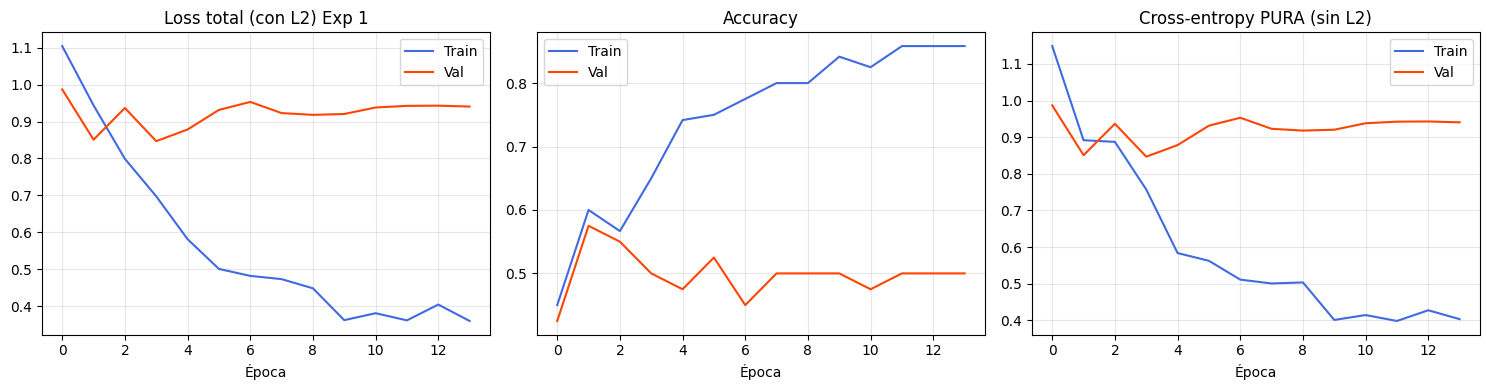

  EXPERIMENTO: Exp 1: EfficientNetB0 (preprocess corregido)
  Backbone congelado, head 256+dropout 0.4

--- VAL --- (selección de modelo)
  Acc: 0.500 | Bal Acc: 0.479 | F1 macro: 0.487
  F1 Mel: 0.429 | AUC Mel: 0.879 | AP Mel: 0.685
  Sens Mel: 37.5% | Spec Mel: 90.6%

--- TEST --- (reportable)
  Acc: 0.600 | Bal Acc: 0.604 | F1 macro: 0.622
  F1 Mel: 0.714 | AUC Mel: 0.898 | AP Mel: 0.793
  Sens Mel: 62.5% | Spec Mel: 96.9%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.67      0.50      0.57        16
Atypical Nevus       0.50      0.69      0.58        16
      Melanoma       0.83      0.62      0.71         8

      accuracy                           0.60        40
     macro avg       0.67      0.60      0.62        40
  weighted avg       0.63      0.60      0.60        40



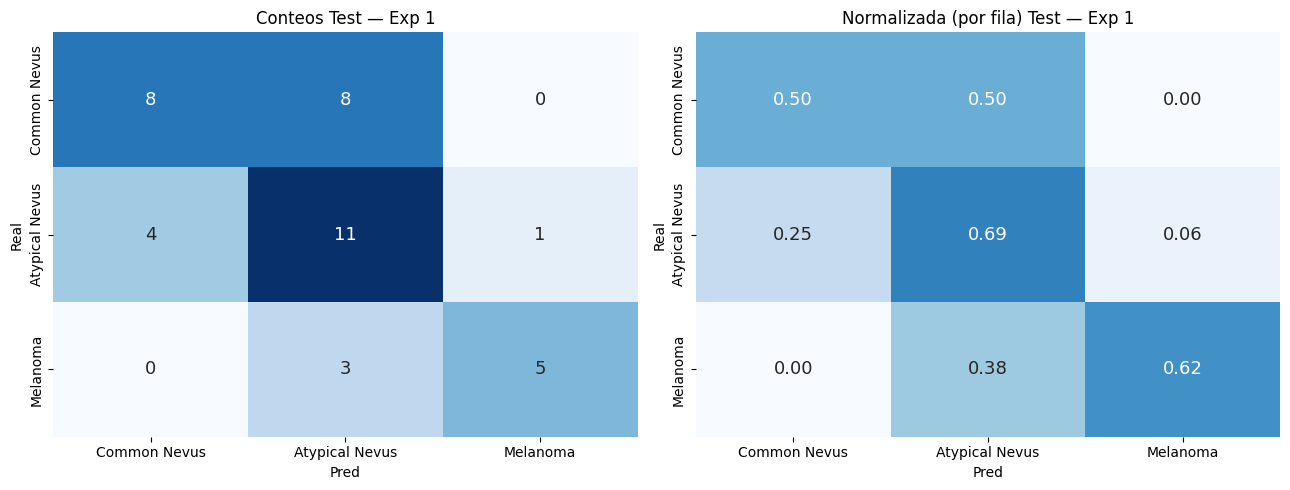

In [9]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

model, base = build_efficientnetb0(dropout=0.4)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=make_metrics())

history = model.fit(train_ds, validation_data=val_ds, epochs=50,
                    class_weight=class_weights,
                    callbacks=callbacks_estandar(patience=10), verbose=2)
plot_history(history, "Exp 1")
evaluar_y_registrar(model, "Exp 1: EfficientNetB0 (preprocess corregido)",
                    descripcion="Backbone congelado, head 256+dropout 0.4")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 1")


### Experimento 2: ResNet50 últimas 30 capas

Epoch 1/50


I0000 00:00:1779072481.332715   87571 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47735__.230
I0000 00:00:1779072490.112680   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47735__.230


8/8 - 26s - 3s/step - accuracy: 0.4500 - categorical_crossentropy: 1.5615 - loss: 5.9866 - val_accuracy: 0.4750 - val_categorical_crossentropy: 1.0041 - val_loss: 5.5073 - learning_rate: 2.0000e-04
Epoch 2/50
8/8 - 1s - 83ms/step - accuracy: 0.6583 - categorical_crossentropy: 0.9618 - loss: 5.3237 - val_accuracy: 0.4750 - val_categorical_crossentropy: 1.0656 - val_loss: 5.5372 - learning_rate: 2.0000e-04
Epoch 3/50
8/8 - 1s - 84ms/step - accuracy: 0.7333 - categorical_crossentropy: 0.7900 - loss: 5.1350 - val_accuracy: 0.4500 - val_categorical_crossentropy: 1.1332 - val_loss: 5.5727 - learning_rate: 2.0000e-04
Epoch 4/50
8/8 - 1s - 82ms/step - accuracy: 0.8083 - categorical_crossentropy: 0.5989 - loss: 4.9458 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.2659 - val_loss: 5.6736 - learning_rate: 2.0000e-04
Epoch 5/50
8/8 - 1s - 83ms/step - accuracy: 0.8667 - categorical_crossentropy: 0.3350 - loss: 4.6853 - val_accuracy: 0.5500 - val_categorical_crossentropy: 1.2730 - val_los

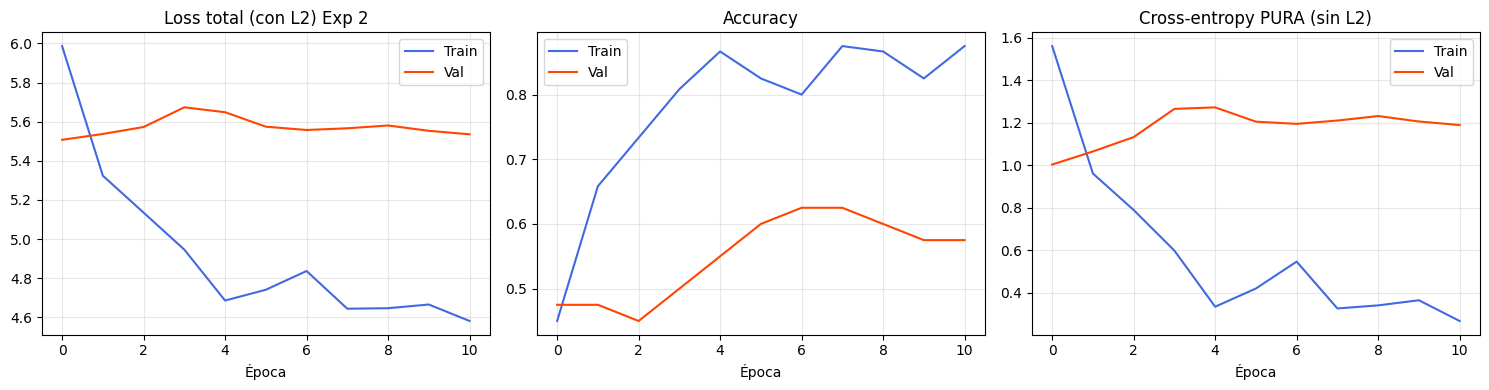

  EXPERIMENTO: Exp 2: ResNet50 (últimas 30 capas)
  L2=0.01, dropout=0.5, dense 256

--- VAL --- (selección de modelo)
  Acc: 0.475 | Bal Acc: 0.417 | F1 macro: 0.410
  F1 Mel: 0.167 | AUC Mel: 0.859 | AP Mel: 0.500
  Sens Mel: 12.5% | Spec Mel: 90.6%

--- TEST --- (reportable)
  Acc: 0.500 | Bal Acc: 0.438 | F1 macro: 0.429
  F1 Mel: 0.222 | AUC Mel: 0.855 | AP Mel: 0.824
  Sens Mel: 12.5% | Spec Mel: 100.0%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.52      0.69      0.59        16
Atypical Nevus       0.44      0.50      0.47        16
      Melanoma       1.00      0.12      0.22         8

      accuracy                           0.50        40
     macro avg       0.66      0.44      0.43        40
  weighted avg       0.59      0.50      0.47        40



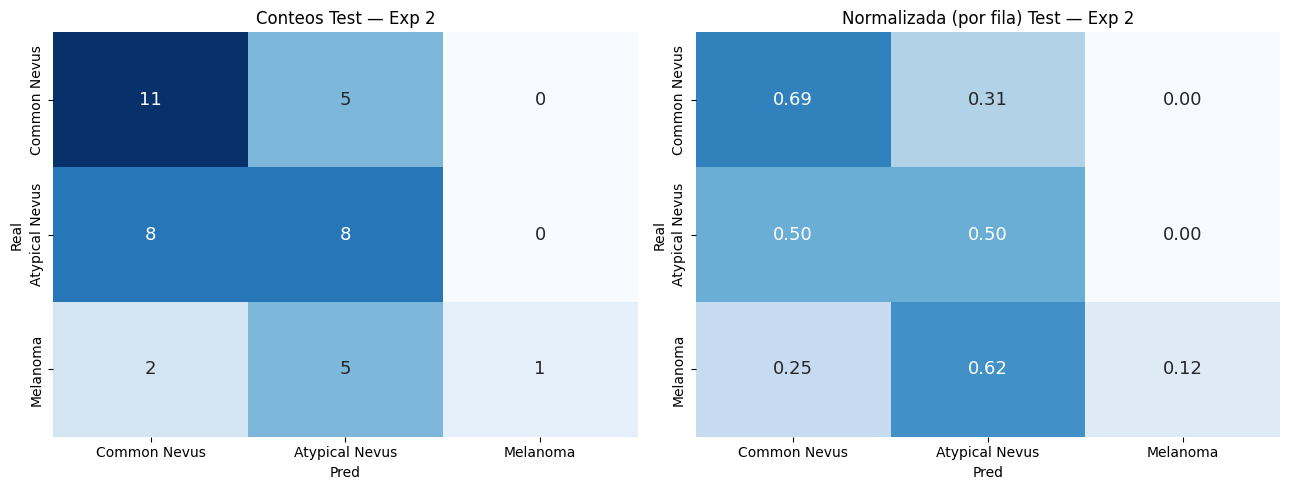

In [10]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

model, base = build_resnet50(unfreeze_last=30, l2=0.01, dropout=0.5, dense_units=256)
model.compile(optimizer=tf.keras.optimizers.Adam(2e-4),
              loss='sparse_categorical_crossentropy',
              metrics=make_metrics())

history = model.fit(train_ds, validation_data=val_ds, epochs=50,
                    class_weight=class_weights,
                    callbacks=callbacks_estandar(patience=10), verbose=2)
plot_history(history, "Exp 2")
evaluar_y_registrar(model, "Exp 2: ResNet50 (últimas 30 capas)",
                    descripcion="L2=0.01, dropout=0.5, dense 256")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 2")


### Experimento 3: ResNet50 — Fine-tuning global

**Cambio metodológico**: en lugar de continuar el modelo del Exp 2, partimos limpio.
Primero entrenamos solo la cabeza (10 épocas, LR 1e-3), después descongelamos todo
y bajamos LR a 1e-5. Esto evita el problema de "destruir pesos" mencionado en la versión
anterior.

Fase 1: entrenando solo cabeza
Epoch 1/15


I0000 00:00:1779072518.745157   87573 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_70876__.194
I0000 00:00:1779072521.592019   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_70876__.194


8/8 - 13s - 2s/step - accuracy: 0.4583 - categorical_crossentropy: 1.6169 - loss: 5.8876 - val_accuracy: 0.4250 - val_categorical_crossentropy: 1.3230 - val_loss: 5.4531 - learning_rate: 0.0010
Epoch 2/15
8/8 - 1s - 69ms/step - accuracy: 0.6167 - categorical_crossentropy: 1.1516 - loss: 5.0115 - val_accuracy: 0.5500 - val_categorical_crossentropy: 1.4613 - val_loss: 5.2967 - learning_rate: 0.0010
Epoch 3/15
8/8 - 1s - 68ms/step - accuracy: 0.7083 - categorical_crossentropy: 0.7308 - loss: 4.3390 - val_accuracy: 0.5750 - val_categorical_crossentropy: 1.6662 - val_loss: 5.2354 - learning_rate: 0.0010
Epoch 4/15
8/8 - 1s - 69ms/step - accuracy: 0.7250 - categorical_crossentropy: 0.7537 - loss: 4.1343 - val_accuracy: 0.6000 - val_categorical_crossentropy: 1.2029 - val_loss: 4.5337 - learning_rate: 0.0010
Epoch 5/15
8/8 - 1s - 70ms/step - accuracy: 0.7500 - categorical_crossentropy: 0.6262 - loss: 3.7859 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.2650 - val_loss: 4.3873 - lear

I0000 00:00:1779072555.849328   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_124811__.406
I0000 00:00:1779072575.400347   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_124811__.406
I0000 00:00:1779072580.935899   92477 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_48', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1779072590.251728   87570 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_48', 24 bytes spill stores, 24 bytes spill loads



8/8 - 60s - 8s/step - accuracy: 0.7333 - categorical_crossentropy: 0.9015 - loss: 2.9114 - val_accuracy: 0.6000 - val_categorical_crossentropy: 0.9633 - val_loss: 3.0977 - learning_rate: 1.0000e-05
Epoch 2/40
8/8 - 1s - 158ms/step - accuracy: 0.7000 - categorical_crossentropy: 0.7618 - loss: 2.8023 - val_accuracy: 0.6750 - val_categorical_crossentropy: 1.0199 - val_loss: 3.1504 - learning_rate: 1.0000e-05
Epoch 3/40
8/8 - 1s - 156ms/step - accuracy: 0.6833 - categorical_crossentropy: 0.7977 - loss: 2.8251 - val_accuracy: 0.6000 - val_categorical_crossentropy: 1.0984 - val_loss: 3.2250 - learning_rate: 1.0000e-05
Epoch 4/40
8/8 - 1s - 158ms/step - accuracy: 0.7667 - categorical_crossentropy: 0.7484 - loss: 2.7721 - val_accuracy: 0.6000 - val_categorical_crossentropy: 1.1751 - val_loss: 3.2979 - learning_rate: 1.0000e-05
Epoch 5/40
8/8 - 1s - 159ms/step - accuracy: 0.7833 - categorical_crossentropy: 0.5095 - loss: 2.5845 - val_accuracy: 0.6000 - val_categorical_crossentropy: 1.2230 - val

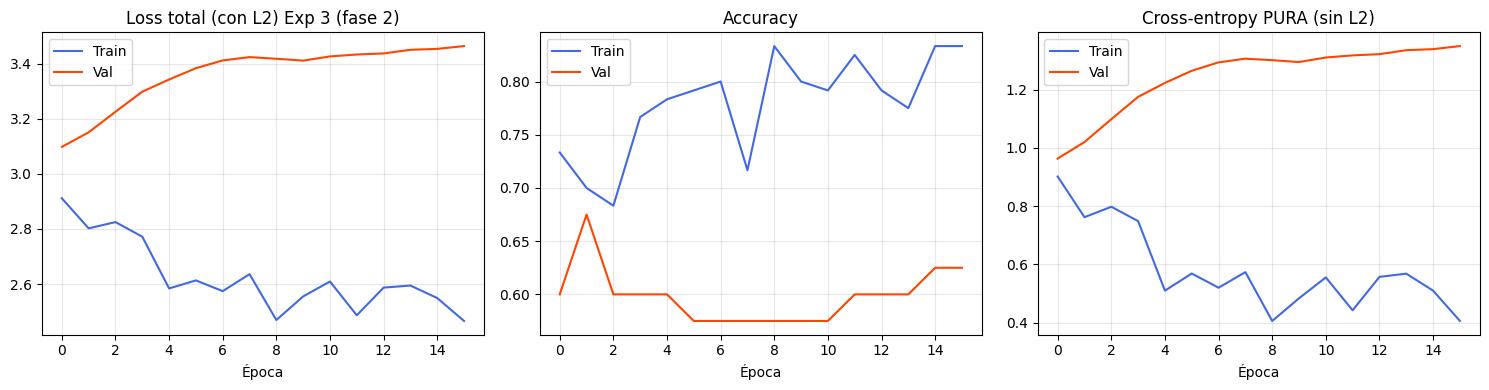

  EXPERIMENTO: Exp 3: ResNet50 fine-tuning global (two-stage)
  Fase 1: head LR=1e-3, 15 ep. Fase 2: full LR=1e-5, hasta 40 ep

--- VAL --- (selección de modelo)
  Acc: 0.600 | Bal Acc: 0.646 | F1 macro: 0.625
  F1 Mel: 0.778 | AUC Mel: 0.984 | AP Mel: 0.958
  Sens Mel: 87.5% | Spec Mel: 90.6%

--- TEST --- (reportable)
  Acc: 0.650 | Bal Acc: 0.646 | F1 macro: 0.673
  F1 Mel: 0.769 | AUC Mel: 0.961 | AP Mel: 0.887
  Sens Mel: 62.5% | Spec Mel: 100.0%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.64      0.56      0.60        16
Atypical Nevus       0.57      0.75      0.65        16
      Melanoma       1.00      0.62      0.77         8

      accuracy                           0.65        40
     macro avg       0.74      0.65      0.67        40
  weighted avg       0.69      0.65      0.65        40



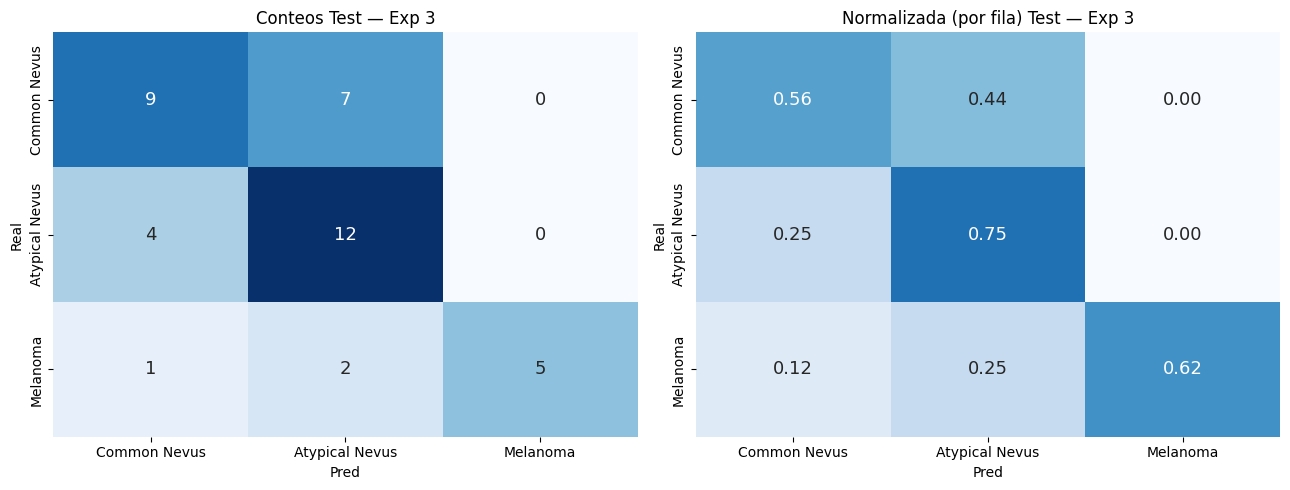

In [11]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

# Fase 1: solo cabeza
model, base = build_resnet50(unfreeze_last=0, l2=0.01, dropout=0.5, dense_units=256)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=make_metrics())
print("Fase 1: entrenando solo cabeza")
history1 = model.fit(train_ds, validation_data=val_ds, epochs=15,
                     class_weight=class_weights,
                     callbacks=callbacks_estandar(patience=6), verbose=2)

# Fase 2: descongelar todo y bajar LR
base.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy', metrics=make_metrics())
print("\nFase 2: descongelando todo el backbone con LR=1e-5")
history2 = model.fit(train_ds, validation_data=val_ds, epochs=40,
                     class_weight=class_weights,
                     callbacks=callbacks_estandar(patience=15), verbose=2)

plot_history(history2, "Exp 3 (fase 2)")
evaluar_y_registrar(model, "Exp 3: ResNet50 fine-tuning global (two-stage)",
                    descripcion="Fase 1: head LR=1e-3, 15 ep. Fase 2: full LR=1e-5, hasta 40 ep")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 3")


### Experimento 4: ResNet50 + Data Augmentation agresivo

Epoch 1/50


I0000 00:00:1779072629.212504   87568 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_155195__.230
I0000 00:00:1779072633.609359   87571 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_155195__.230


8/8 - 19s - 2s/step - accuracy: 0.3917 - categorical_crossentropy: 1.8495 - loss: 6.2369 - val_accuracy: 0.4000 - val_categorical_crossentropy: 1.2597 - val_loss: 5.7614 - learning_rate: 2.0000e-04
Epoch 2/50
8/8 - 1s - 92ms/step - accuracy: 0.6333 - categorical_crossentropy: 1.0605 - loss: 5.4427 - val_accuracy: 0.4250 - val_categorical_crossentropy: 1.3919 - val_loss: 5.8627 - learning_rate: 2.0000e-04
Epoch 3/50
8/8 - 1s - 92ms/step - accuracy: 0.6917 - categorical_crossentropy: 0.9277 - loss: 5.2652 - val_accuracy: 0.4500 - val_categorical_crossentropy: 1.4309 - val_loss: 5.8707 - learning_rate: 2.0000e-04
Epoch 4/50
8/8 - 1s - 91ms/step - accuracy: 0.7833 - categorical_crossentropy: 0.6331 - loss: 4.9804 - val_accuracy: 0.4500 - val_categorical_crossentropy: 1.4360 - val_loss: 5.8435 - learning_rate: 2.0000e-04
Epoch 5/50
8/8 - 1s - 91ms/step - accuracy: 0.7500 - categorical_crossentropy: 0.6761 - loss: 4.9949 - val_accuracy: 0.4250 - val_categorical_crossentropy: 1.5567 - val_los

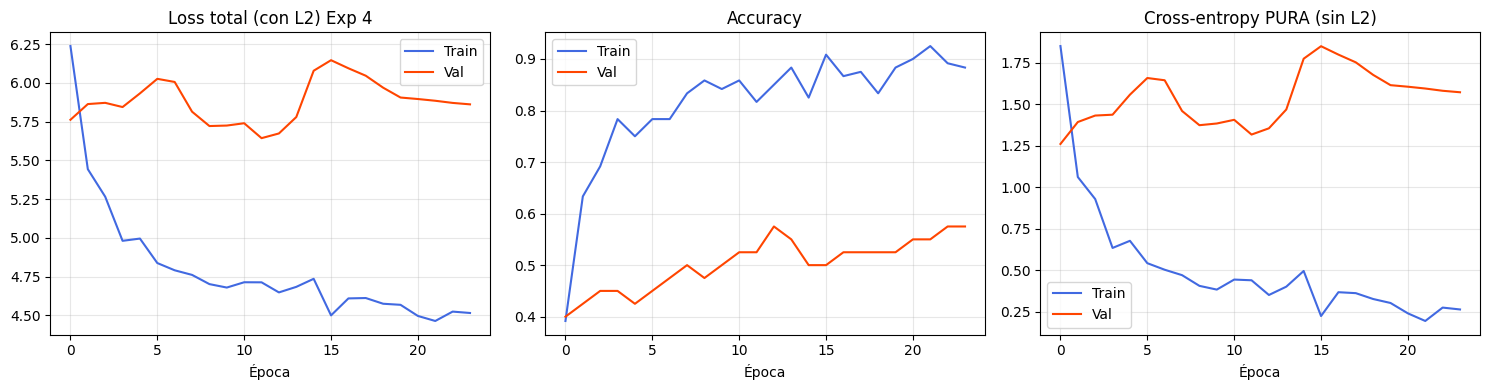

  EXPERIMENTO: Exp 4: ResNet50 + DA Agresivo
  Flip, rotación libre, zoom, brightness, contraste

--- VAL --- (selección de modelo)
  Acc: 0.525 | Bal Acc: 0.604 | F1 macro: 0.502
  F1 Mel: 0.727 | AUC Mel: 0.984 | AP Mel: 0.942
  Sens Mel: 100.0% | Spec Mel: 81.2%

--- TEST --- (reportable)
  Acc: 0.700 | Bal Acc: 0.729 | F1 macro: 0.705
  F1 Mel: 0.737 | AUC Mel: 0.863 | AP Mel: 0.779
  Sens Mel: 87.5% | Spec Mel: 87.5%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.90      0.56      0.69        16
Atypical Nevus       0.63      0.75      0.69        16
      Melanoma       0.64      0.88      0.74         8

      accuracy                           0.70        40
     macro avg       0.72      0.73      0.70        40
  weighted avg       0.74      0.70      0.70        40



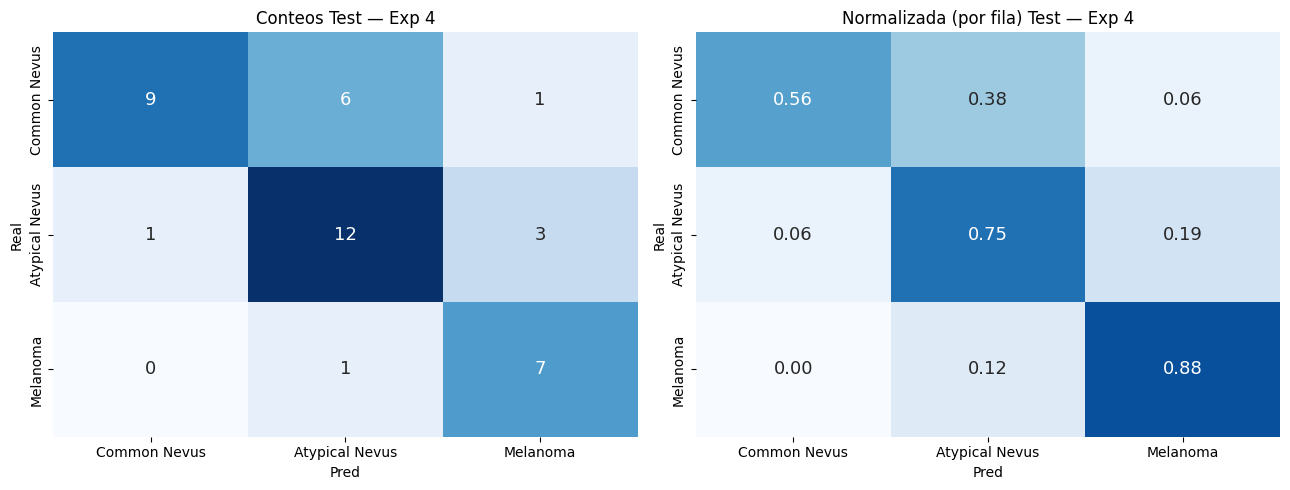

In [12]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

train_ds_aug = build_dataset(fp_train, y_train, shuffle=True,
                             augment=data_augmentation_aggressive)

model, base = build_resnet50(unfreeze_last=30, l2=0.01, dropout=0.5, dense_units=256)
model.compile(optimizer=tf.keras.optimizers.Adam(2e-4),
              loss='sparse_categorical_crossentropy', metrics=make_metrics())

history = model.fit(train_ds_aug, validation_data=val_ds, epochs=50,
                    class_weight=class_weights,
                    callbacks=callbacks_estandar(patience=12), verbose=2)
plot_history(history, "Exp 4")
evaluar_y_registrar(model, "Exp 4: ResNet50 + DA Agresivo",
                    descripcion="Flip, rotación libre, zoom, brightness, contraste")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 4")


### Experimento 5: MobileNetV2

Epoch 1/50


I0000 00:00:1779072671.540234   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_184145__.181
E0000 00:00:1779072672.587879   87570 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1779072681.920010   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_184145__.181


8/8 - 31s - 4s/step - accuracy: 0.4333 - categorical_crossentropy: 1.3022 - loss: 3.6253 - val_accuracy: 0.3750 - val_categorical_crossentropy: 1.3455 - val_loss: 3.6538 - learning_rate: 1.0000e-04
Epoch 2/50
8/8 - 0s - 55ms/step - accuracy: 0.5417 - categorical_crossentropy: 1.0111 - loss: 3.2910 - val_accuracy: 0.4250 - val_categorical_crossentropy: 1.4075 - val_loss: 3.7046 - learning_rate: 1.0000e-04
Epoch 3/50
8/8 - 0s - 53ms/step - accuracy: 0.5833 - categorical_crossentropy: 0.8851 - loss: 3.1050 - val_accuracy: 0.4000 - val_categorical_crossentropy: 1.7480 - val_loss: 4.0343 - learning_rate: 1.0000e-04
Epoch 4/50
8/8 - 0s - 54ms/step - accuracy: 0.5750 - categorical_crossentropy: 0.7919 - loss: 3.0030 - val_accuracy: 0.4000 - val_categorical_crossentropy: 2.0134 - val_loss: 4.2885 - learning_rate: 1.0000e-04
Epoch 5/50
8/8 - 0s - 53ms/step - accuracy: 0.6250 - categorical_crossentropy: 0.7333 - loss: 2.9296 - val_accuracy: 0.4000 - val_categorical_crossentropy: 2.3415 - val_los

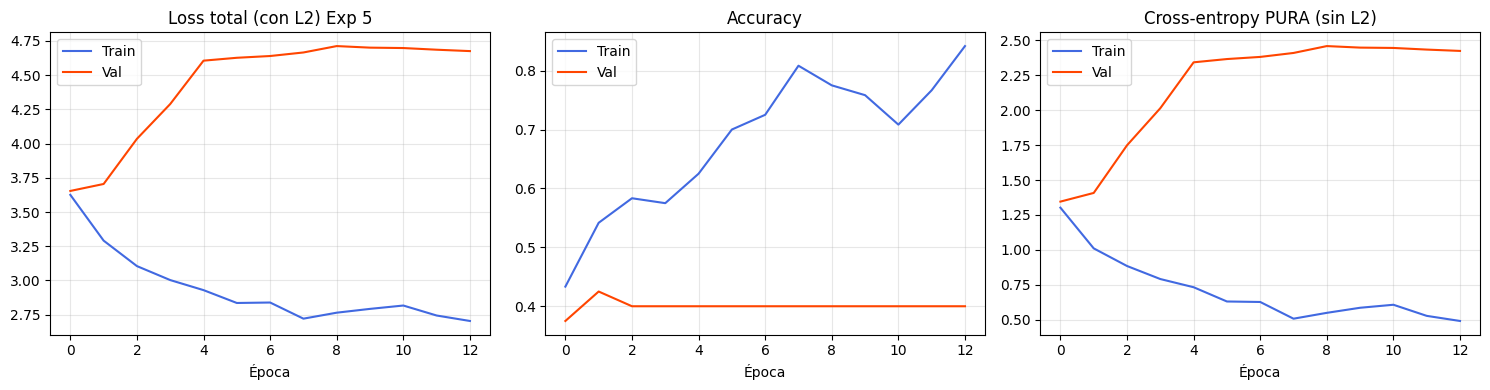

  EXPERIMENTO: Exp 5: MobileNetV2 + DA Agresivo
  Backbone ligero, últimas 40 capas

--- VAL --- (selección de modelo)
  Acc: 0.375 | Bal Acc: 0.333 | F1 macro: 0.247
  F1 Mel: 0.182 | AUC Mel: 0.582 | AP Mel: 0.353
  Sens Mel: 12.5% | Spec Mel: 93.8%

--- TEST --- (reportable)
  Acc: 0.375 | Bal Acc: 0.312 | F1 macro: 0.189
  F1 Mel: 0.000 | AUC Mel: 0.691 | AP Mel: 0.335
  Sens Mel: 0.0% | Spec Mel: 100.0%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.41      0.94      0.57        16
Atypical Nevus       0.00      0.00      0.00        16
      Melanoma       0.00      0.00      0.00         8

      accuracy                           0.38        40
     macro avg       0.14      0.31      0.19        40
  weighted avg       0.16      0.38      0.23        40



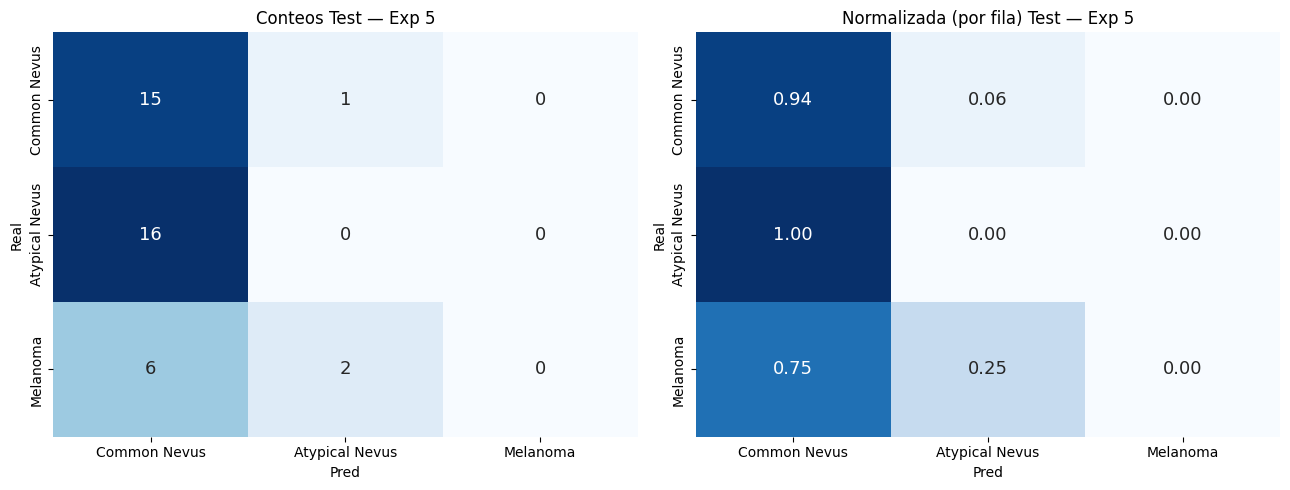

In [13]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

model, base = build_mobilenetv2(unfreeze_last=40, l2=0.01, dropout=0.4)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='sparse_categorical_crossentropy', metrics=make_metrics())

history = model.fit(train_ds_aug, validation_data=val_ds, epochs=50,
                    class_weight=class_weights,
                    callbacks=callbacks_estandar(patience=12), verbose=2)
plot_history(history, "Exp 5")
evaluar_y_registrar(model, "Exp 5: MobileNetV2 + DA Agresivo",
                    descripcion="Backbone ligero, últimas 40 capas")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 5")


### Experimento 6: ResNet50 regularizada (clasificador pequeño)

Epoch 1/50


I0000 00:00:1779072715.058109   87569 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_204372__.194
I0000 00:00:1779072717.962286   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_204372__.194


8/8 - 14s - 2s/step - accuracy: 0.3833 - categorical_crossentropy: 1.7782 - loss: 4.1774 - val_accuracy: 0.4000 - val_categorical_crossentropy: 1.4933 - val_loss: 3.7943 - learning_rate: 0.0010
Epoch 2/50
8/8 - 1s - 67ms/step - accuracy: 0.5083 - categorical_crossentropy: 1.2940 - loss: 3.4098 - val_accuracy: 0.4000 - val_categorical_crossentropy: 1.8069 - val_loss: 3.9725 - learning_rate: 0.0010
Epoch 3/50
8/8 - 1s - 69ms/step - accuracy: 0.5083 - categorical_crossentropy: 1.2958 - loss: 3.2957 - val_accuracy: 0.4500 - val_categorical_crossentropy: 1.7974 - val_loss: 3.8360 - learning_rate: 0.0010
Epoch 4/50
8/8 - 1s - 77ms/step - accuracy: 0.5833 - categorical_crossentropy: 1.0306 - loss: 2.9175 - val_accuracy: 0.4500 - val_categorical_crossentropy: 1.6328 - val_loss: 3.5547 - learning_rate: 0.0010
Epoch 5/50
8/8 - 1s - 82ms/step - accuracy: 0.6250 - categorical_crossentropy: 1.0669 - loss: 2.8418 - val_accuracy: 0.4500 - val_categorical_crossentropy: 1.3234 - val_loss: 3.1397 - lear

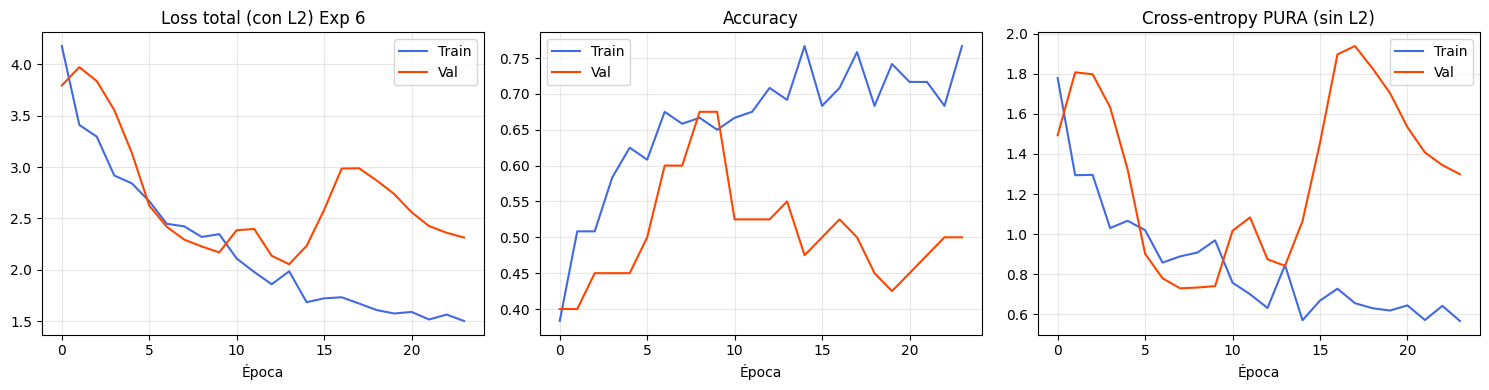

  EXPERIMENTO: Exp 6: ResNet50 regularizada
  Backbone TOTALMENTE congelado, clasificador 64 + L2=0.02 + Dropout=0.6

--- VAL --- (selección de modelo)
  Acc: 0.550 | Bal Acc: 0.625 | F1 macro: 0.542
  F1 Mel: 0.842 | AUC Mel: 0.980 | AP Mel: 0.938
  Sens Mel: 100.0% | Spec Mel: 90.6%

--- TEST --- (reportable)
  Acc: 0.675 | Bal Acc: 0.688 | F1 macro: 0.700
  F1 Mel: 0.857 | AUC Mel: 0.988 | AP Mel: 0.959
  Sens Mel: 75.0% | Spec Mel: 100.0%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.78      0.44      0.56        16
Atypical Nevus       0.56      0.88      0.68        16
      Melanoma       1.00      0.75      0.86         8

      accuracy                           0.68        40
     macro avg       0.78      0.69      0.70        40
  weighted avg       0.74      0.68      0.67        40



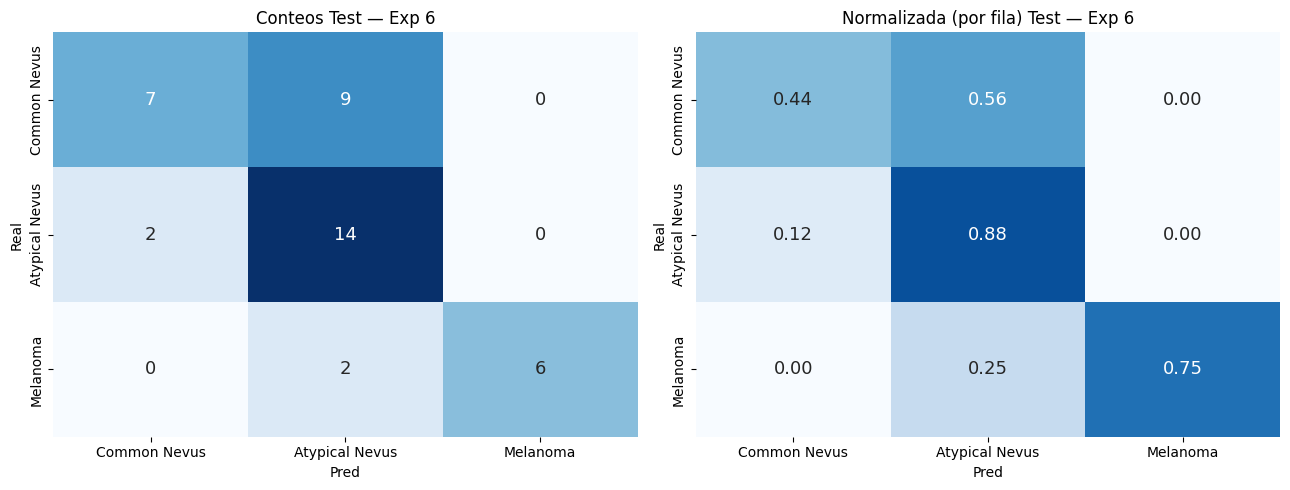

In [14]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

model, base = build_resnet50(unfreeze_last=0, l2=0.02, dropout=0.6, dense_units=64)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=make_metrics())

history = model.fit(train_ds_aug, validation_data=val_ds, epochs=50,
                    class_weight=class_weights,
                    callbacks=callbacks_estandar(patience=10), verbose=2)
plot_history(history, "Exp 6")
evaluar_y_registrar(model, "Exp 6: ResNet50 regularizada",
                    descripcion="Backbone TOTALMENTE congelado, clasificador 64 + L2=0.02 + Dropout=0.6")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 6")


### Experimento 7: ResNet50 ultra-regularizada (anti-overfitting extremo)

Epoch 1/50


I0000 00:00:1779072749.956662   87573 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_234597__.195
I0000 00:00:1779072752.885910   87569 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_234597__.195


8/8 - 14s - 2s/step - accuracy: 0.2750 - categorical_crossentropy: 2.3645 - loss: 11.5715 - val_accuracy: 0.4000 - val_categorical_crossentropy: 1.1559 - val_loss: 9.5202 - learning_rate: 0.0010
Epoch 2/50
8/8 - 1s - 77ms/step - accuracy: 0.5000 - categorical_crossentropy: 1.6562 - loss: 9.5170 - val_accuracy: 0.4750 - val_categorical_crossentropy: 0.9340 - val_loss: 8.3607 - learning_rate: 0.0010
Epoch 3/50
8/8 - 1s - 79ms/step - accuracy: 0.4500 - categorical_crossentropy: 1.7313 - loss: 8.7448 - val_accuracy: 0.4750 - val_categorical_crossentropy: 1.1168 - val_loss: 7.7790 - learning_rate: 0.0010
Epoch 4/50
8/8 - 1s - 79ms/step - accuracy: 0.4500 - categorical_crossentropy: 1.6426 - loss: 7.9276 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.2015 - val_loss: 7.2340 - learning_rate: 0.0010
Epoch 5/50
8/8 - 1s - 81ms/step - accuracy: 0.4917 - categorical_crossentropy: 1.5349 - loss: 7.1599 - val_accuracy: 0.4750 - val_categorical_crossentropy: 1.2315 - val_loss: 6.7318 - lea

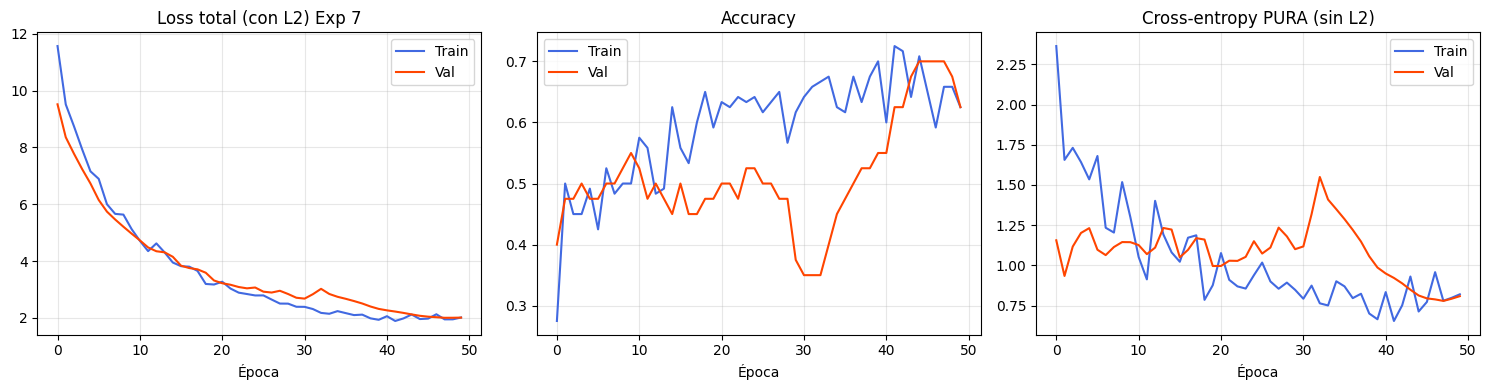

  EXPERIMENTO: Exp 7: ResNet50 ultra-regularizada
  L2=0.08, Dropout 0.5 + 0.65, dense 64. Mejor de la versión original.

--- VAL --- (selección de modelo)
  Acc: 0.700 | Bal Acc: 0.750 | F1 macro: 0.692
  F1 Mel: 0.727 | AUC Mel: 0.984 | AP Mel: 0.942
  Sens Mel: 100.0% | Spec Mel: 81.2%

--- TEST --- (reportable)
  Acc: 0.575 | Bal Acc: 0.604 | F1 macro: 0.579
  F1 Mel: 0.632 | AUC Mel: 0.957 | AP Mel: 0.886
  Sens Mel: 75.0% | Spec Mel: 84.4%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.59      0.62      0.61        16
Atypical Nevus       0.58      0.44      0.50        16
      Melanoma       0.55      0.75      0.63         8

      accuracy                           0.57        40
     macro avg       0.57      0.60      0.58        40
  weighted avg       0.58      0.57      0.57        40



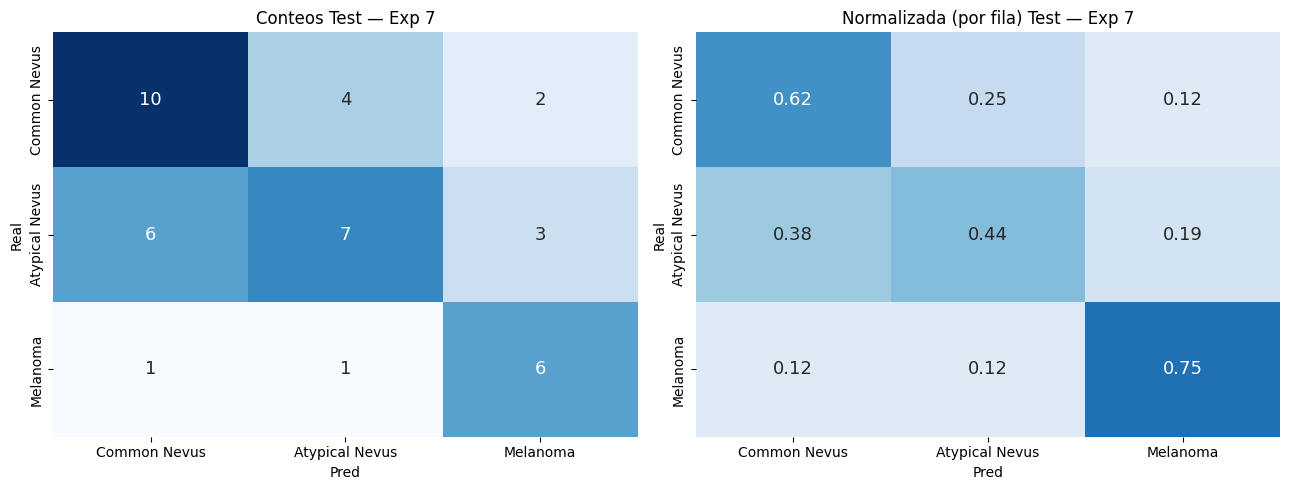

In [15]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

def build_ultra_stable_resnet():
    inputs = layers.Input(shape=(224,224,3))
    x = PreprocessLayer(backbone='resnet', name='resnet_preprocess')(inputs)
    base = ResNet50(include_top=False, weights='imagenet', input_shape=(224,224,3))
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5, seed=SEED)(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(0.08))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.65, seed=SEED)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, out), base

model, base = build_ultra_stable_resnet()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=make_metrics())

history = model.fit(train_ds_aug, validation_data=val_ds, epochs=50,
                    class_weight=class_weights,
                    callbacks=callbacks_estandar(patience=12), verbose=2)
plot_history(history, "Exp 7")
evaluar_y_registrar(model, "Exp 7: ResNet50 ultra-regularizada",
                    descripcion="L2=0.08, Dropout 0.5 + 0.65, dense 64. Mejor de la versión original.")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 7")

# Guardamos este modelo (era el mejor de la versión anterior)
model.save("modelo_exp7_ultra_regularizado.keras")


## 8. Experimentos nuevos

A partir de aquí los experimentos no estaban en la versión original.


### Experimento 8: Two-stage fine-tuning correcto

Versión refinada del two-stage:
- **Fase 1 (warmup)**: solo head, LR=1e-3, 15 épocas
- **Fase 2 (fine-tune)**: descongelar últimas 30 capas, LR=1e-5, hasta 40 épocas
- Augmentation agresivo en ambas fases


Fase 1 — Solo head, LR=1e-3
Epoch 1/15


I0000 00:00:1779072808.180895   87572 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_288836__.194
I0000 00:00:1779072811.167366   87572 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_288836__.194


8/8 - 14s - 2s/step - accuracy: 0.4000 - categorical_crossentropy: 1.7023 - loss: 3.9506 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.0635 - val_loss: 3.2872 - learning_rate: 0.0010
Epoch 2/15
8/8 - 1s - 72ms/step - accuracy: 0.5833 - categorical_crossentropy: 1.2729 - loss: 3.2764 - val_accuracy: 0.5250 - val_categorical_crossentropy: 1.2138 - val_loss: 3.3145 - learning_rate: 0.0010
Epoch 3/15
8/8 - 1s - 77ms/step - accuracy: 0.6500 - categorical_crossentropy: 0.9884 - loss: 2.9333 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.2827 - val_loss: 3.2753 - learning_rate: 0.0010
Epoch 4/15
8/8 - 1s - 69ms/step - accuracy: 0.6833 - categorical_crossentropy: 0.9576 - loss: 2.7687 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.7562 - val_loss: 3.6511 - learning_rate: 0.0010
Epoch 5/15
8/8 - 1s - 68ms/step - accuracy: 0.6833 - categorical_crossentropy: 0.9177 - loss: 2.6820 - val_accuracy: 0.5250 - val_categorical_crossentropy: 1.5396 - val_loss: 3.3471 - lear

I0000 00:00:1779072829.115432   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_309874__.230
I0000 00:00:1779072833.693721   87572 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_309874__.230


8/8 - 19s - 2s/step - accuracy: 0.5167 - categorical_crossentropy: 1.3241 - loss: 3.1739 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.2475 - val_loss: 3.2373 - learning_rate: 1.0000e-05
Epoch 2/40
8/8 - 1s - 100ms/step - accuracy: 0.6000 - categorical_crossentropy: 1.0911 - loss: 2.9369 - val_accuracy: 0.5250 - val_categorical_crossentropy: 1.2192 - val_loss: 3.2065 - learning_rate: 1.0000e-05
Epoch 3/40
8/8 - 1s - 100ms/step - accuracy: 0.6000 - categorical_crossentropy: 1.0226 - loss: 2.9209 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.2060 - val_loss: 3.1907 - learning_rate: 1.0000e-05
Epoch 4/40
8/8 - 1s - 102ms/step - accuracy: 0.6417 - categorical_crossentropy: 1.0612 - loss: 2.8926 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.1881 - val_loss: 3.1704 - learning_rate: 1.0000e-05
Epoch 5/40
8/8 - 1s - 99ms/step - accuracy: 0.5667 - categorical_crossentropy: 1.1289 - loss: 2.9675 - val_accuracy: 0.4500 - val_categorical_crossentropy: 1.1768 - val_

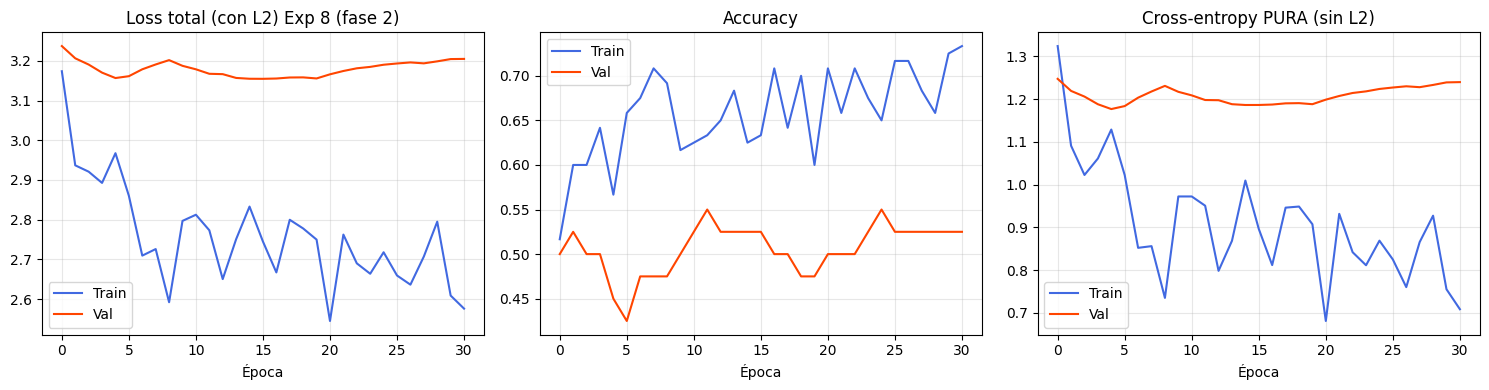

  EXPERIMENTO: Exp 8: Two-stage fine-tuning correcto
  Fase 1: head LR=1e-3. Fase 2: últimas 30 capas LR=1e-5

--- VAL --- (selección de modelo)
  Acc: 0.525 | Bal Acc: 0.604 | F1 macro: 0.538
  F1 Mel: 0.696 | AUC Mel: 0.965 | AP Mel: 0.893
  Sens Mel: 100.0% | Spec Mel: 78.1%

--- TEST --- (reportable)
  Acc: 0.625 | Bal Acc: 0.646 | F1 macro: 0.632
  F1 Mel: 0.706 | AUC Mel: 0.934 | AP Mel: 0.784
  Sens Mel: 75.0% | Spec Mel: 90.6%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.78      0.44      0.56        16
Atypical Nevus       0.55      0.75      0.63        16
      Melanoma       0.67      0.75      0.71         8

      accuracy                           0.62        40
     macro avg       0.66      0.65      0.63        40
  weighted avg       0.66      0.62      0.62        40



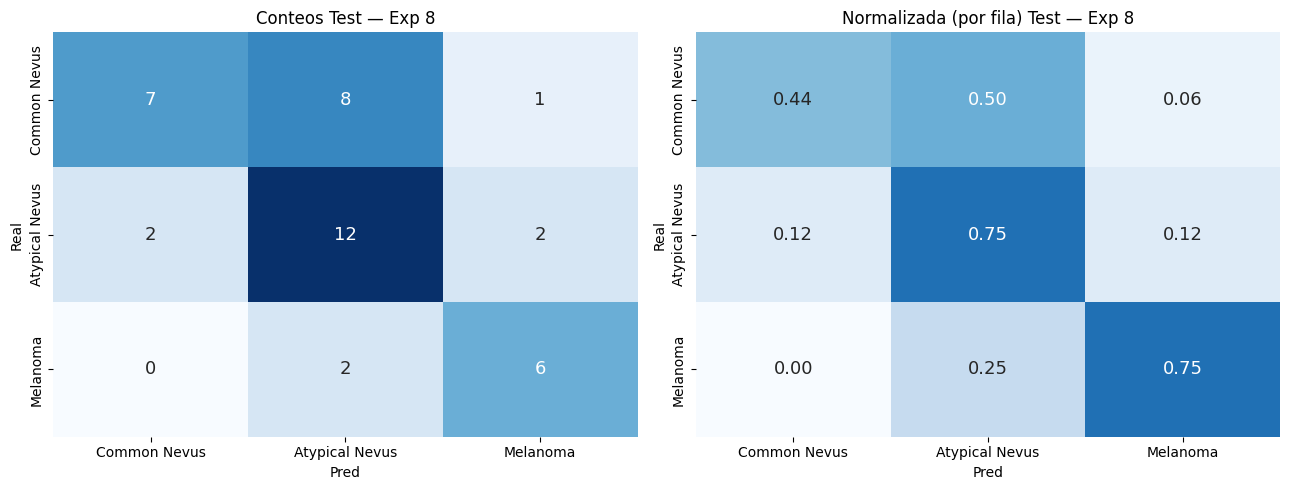

In [16]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

# Fase 1: solo cabeza
model, base = build_resnet50(unfreeze_last=0, l2=0.01, dropout=0.5, dense_units=128)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=make_metrics())
print("Fase 1 — Solo head, LR=1e-3")
h1 = model.fit(train_ds_aug, validation_data=val_ds, epochs=15,
               class_weight=class_weights,
               callbacks=callbacks_estandar(patience=6), verbose=2)

# Fase 2: descongelar últimas 30 capas, LR muy bajo
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy', metrics=make_metrics())
print("\nFase 2 — Últimas 30 capas, LR=1e-5")
h2 = model.fit(train_ds_aug, validation_data=val_ds, epochs=40,
               class_weight=class_weights,
               callbacks=callbacks_estandar(patience=15), verbose=2)

plot_history(h2, "Exp 8 (fase 2)")
evaluar_y_registrar(model, "Exp 8: Two-stage fine-tuning correcto",
                    descripcion="Fase 1: head LR=1e-3. Fase 2: últimas 30 capas LR=1e-5")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 8")


### Experimento 9: Focal Loss

Focal loss `FL(p_t) = -α(1-p_t)^γ log(p_t)` baja el peso de los ejemplos fáciles y
prioriza los difíciles. Apropiado para desbalance de clases.


Epoch 1/50


I0000 00:00:1779072878.653486   87572 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_344595__.229
I0000 00:00:1779072883.250184   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_344595__.229


8/8 - 20s - 2s/step - accuracy: 0.4417 - categorical_crossentropy: 1.6405 - loss: 5.9742 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.3593 - val_loss: 5.6980 - learning_rate: 2.0000e-04
Epoch 2/50
8/8 - 1s - 101ms/step - accuracy: 0.5750 - categorical_crossentropy: 1.2546 - loss: 5.5267 - val_accuracy: 0.5000 - val_categorical_crossentropy: 1.3115 - val_loss: 5.5829 - learning_rate: 2.0000e-04
Epoch 3/50
8/8 - 1s - 101ms/step - accuracy: 0.7167 - categorical_crossentropy: 0.7639 - loss: 5.0385 - val_accuracy: 0.4750 - val_categorical_crossentropy: 1.0049 - val_loss: 5.1148 - learning_rate: 2.0000e-04
Epoch 4/50
8/8 - 1s - 100ms/step - accuracy: 0.6333 - categorical_crossentropy: 1.0297 - loss: 5.2789 - val_accuracy: 0.5250 - val_categorical_crossentropy: 1.0105 - val_loss: 5.0505 - learning_rate: 2.0000e-04
Epoch 5/50
8/8 - 1s - 91ms/step - accuracy: 0.6583 - categorical_crossentropy: 0.9503 - loss: 5.1867 - val_accuracy: 0.4250 - val_categorical_crossentropy: 1.1373 - val_

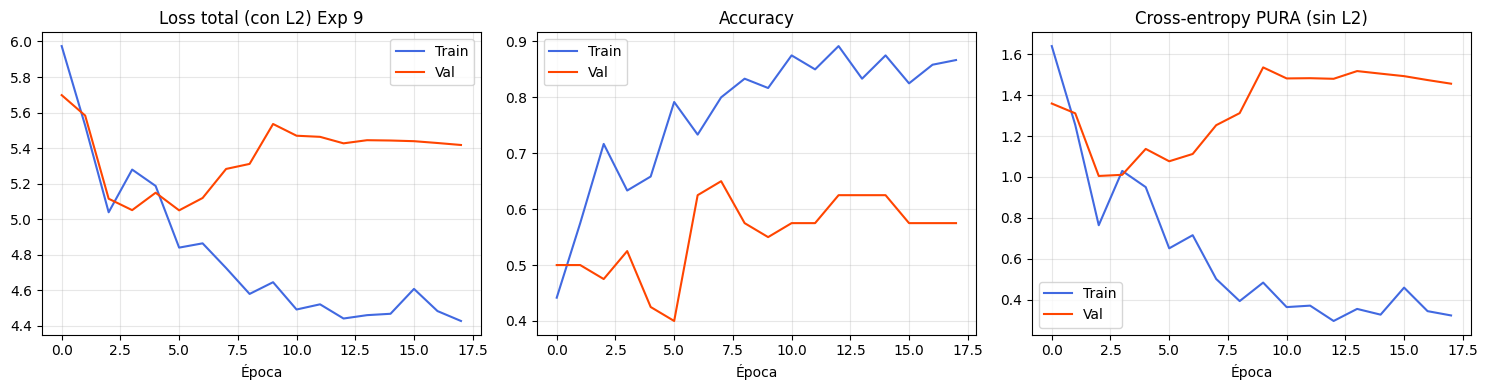

  EXPERIMENTO: Exp 9: ResNet50 + Focal Loss (γ=2, α=[1,1,2])
  Focal loss en lugar de class_weight para manejar desbalance

--- VAL --- (selección de modelo)
  Acc: 0.400 | Bal Acc: 0.458 | F1 macro: 0.428
  F1 Mel: 0.706 | AUC Mel: 0.938 | AP Mel: 0.754
  Sens Mel: 75.0% | Spec Mel: 90.6%

--- TEST --- (reportable)
  Acc: 0.650 | Bal Acc: 0.667 | F1 macro: 0.670
  F1 Mel: 0.800 | AUC Mel: 0.902 | AP Mel: 0.800
  Sens Mel: 75.0% | Spec Mel: 96.9%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.78      0.44      0.56        16
Atypical Nevus       0.54      0.81      0.65        16
      Melanoma       0.86      0.75      0.80         8

      accuracy                           0.65        40
     macro avg       0.73      0.67      0.67        40
  weighted avg       0.70      0.65      0.64        40



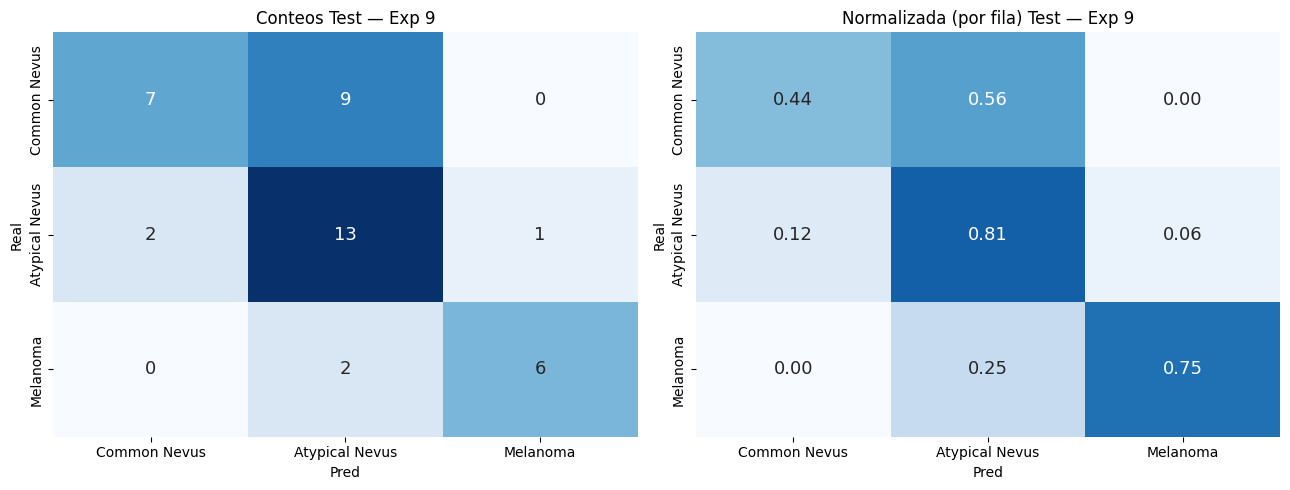

In [17]:
def sparse_categorical_focal_loss(gamma=2.0, alpha=None, from_logits=False):
    """Focal loss para etiquetas enteras (sparse). alpha puede ser un vector por clase."""
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        if from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        # Probabilidad de la clase verdadera
        idx = tf.stack([tf.range(tf.shape(y_true)[0]), tf.reshape(y_true, [-1])], axis=1)
        p_t = tf.gather_nd(y_pred, idx)
        ce = -tf.math.log(p_t)
        focal = tf.pow(1.0 - p_t, gamma) * ce
        if alpha is not None:
            alpha_t = tf.gather(tf.constant(alpha, dtype=tf.float32), tf.reshape(y_true, [-1]))
            focal = alpha_t * focal
        return tf.reduce_mean(focal)
    return loss_fn

K.clear_session(); gc.collect(); set_reproducibility(SEED)

alpha_vec = [1.0, 1.0, 2.0]  # peso extra a melanoma

model, base = build_resnet50(unfreeze_last=30, l2=0.01, dropout=0.5, dense_units=256)
model.compile(optimizer=tf.keras.optimizers.Adam(2e-4),
              loss=sparse_categorical_focal_loss(gamma=2.0, alpha=alpha_vec),
              metrics=['accuracy', tf.keras.metrics.SparseCategoricalCrossentropy(name='categorical_crossentropy')])

history = model.fit(train_ds_aug, validation_data=val_ds, epochs=50,
                    callbacks=callbacks_estandar(patience=12), verbose=2)
plot_history(history, "Exp 9")
evaluar_y_registrar(model, "Exp 9: ResNet50 + Focal Loss (γ=2, α=[1,1,2])",
                    descripcion="Focal loss en lugar de class_weight para manejar desbalance")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 9")


### Experimento 10: Mixup

Mixup combina pares de imágenes y sus labels linealmente. Es muy efectivo en datasets
pequeños porque actúa como regularizador fuerte.


Epoch 1/50


I0000 00:00:1779072919.547322   87569 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_377181__.230
I0000 00:00:1779072924.159199   87573 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_377181__.230


8/8 - 19s - 2s/step - accuracy: 0.5000 - loss: 6.1255 - val_accuracy: 0.4250 - val_loss: 5.6416 - learning_rate: 2.0000e-04
Epoch 2/50
8/8 - 1s - 96ms/step - accuracy: 0.5833 - loss: 5.7265 - val_accuracy: 0.3000 - val_loss: 6.0233 - learning_rate: 2.0000e-04
Epoch 3/50
8/8 - 1s - 93ms/step - accuracy: 0.5583 - loss: 5.7312 - val_accuracy: 0.3000 - val_loss: 6.2722 - learning_rate: 2.0000e-04
Epoch 4/50
8/8 - 1s - 95ms/step - accuracy: 0.6000 - loss: 5.4944 - val_accuracy: 0.3750 - val_loss: 6.3103 - learning_rate: 2.0000e-04
Epoch 5/50
8/8 - 1s - 92ms/step - accuracy: 0.7083 - loss: 5.4254 - val_accuracy: 0.3500 - val_loss: 6.4198 - learning_rate: 2.0000e-04
Epoch 6/50
8/8 - 1s - 98ms/step - accuracy: 0.7250 - loss: 5.2345 - val_accuracy: 0.3750 - val_loss: 6.3496 - learning_rate: 4.0000e-05
Epoch 7/50
8/8 - 1s - 98ms/step - accuracy: 0.7000 - loss: 5.2849 - val_accuracy: 0.3750 - val_loss: 6.2787 - learning_rate: 4.0000e-05
Epoch 8/50
8/8 - 1s - 94ms/step - accuracy: 0.7667 - loss: 5

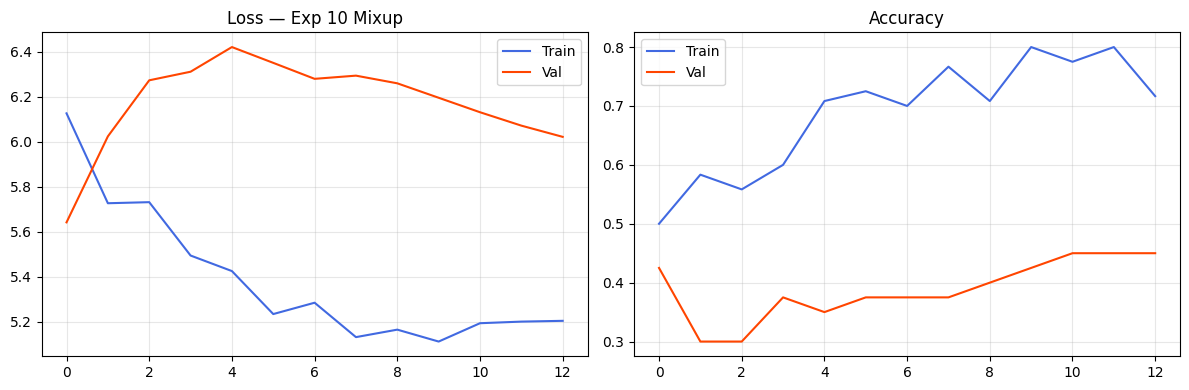

  EXPERIMENTO: Exp 10: ResNet50 + Mixup (α=0.2)
  Mixup combina pares de imágenes, fuerte regularización

--- VAL --- (selección de modelo)
  Acc: 0.425 | Bal Acc: 0.500 | F1 macro: 0.409
  F1 Mel: 0.560 | AUC Mel: 0.867 | AP Mel: 0.507
  Sens Mel: 87.5% | Spec Mel: 68.8%

--- TEST --- (reportable)
  Acc: 0.475 | Bal Acc: 0.500 | F1 macro: 0.471
  F1 Mel: 0.500 | AUC Mel: 0.750 | AP Mel: 0.608
  Sens Mel: 62.5% | Spec Mel: 78.1%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.50      0.31      0.38        16
Atypical Nevus       0.50      0.56      0.53        16
      Melanoma       0.42      0.62      0.50         8

      accuracy                           0.47        40
     macro avg       0.47      0.50      0.47        40
  weighted avg       0.48      0.47      0.47        40



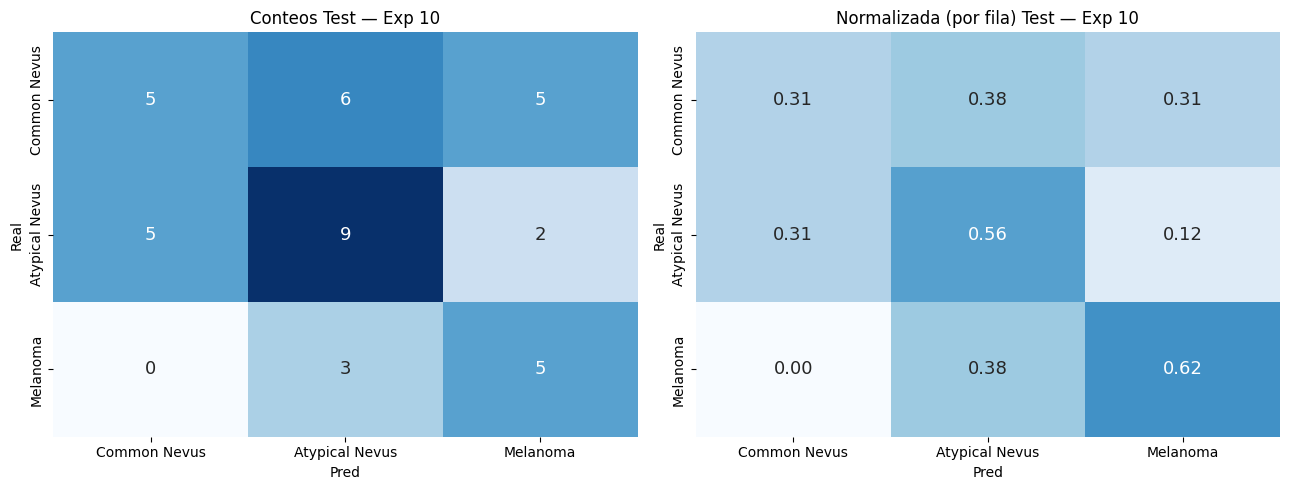

In [18]:
def mixup(images, labels, num_classes=3, alpha=0.2):
    batch_size = tf.shape(images)[0]
    # One-hot las etiquetas
    labels_oh = tf.one_hot(tf.cast(labels, tf.int32), num_classes)
    # Lambda de la distribución Beta(alpha, alpha)
    # Beta(alpha, alpha) usando dos Gamma: Beta(a,b) = G(a) / (G(a) + G(b))
    g1 = tf.random.gamma([batch_size], alpha, dtype=tf.float32)
    g2 = tf.random.gamma([batch_size], alpha, dtype=tf.float32)
    lam = g1 / (g1 + g2 + 1e-9)
    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])
    perm = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam_x * images + (1.0 - lam_x) * tf.gather(images, perm)
    mixed_labels = lam_y * labels_oh + (1.0 - lam_y) * tf.gather(labels_oh, perm)
    return mixed_images, mixed_labels

def build_mixup_dataset(filepaths_arr, labels_arr, augment=None, alpha=0.2):
    ds = tf.data.Dataset.from_tensor_slices((filepaths_arr, labels_arr))
    ds = ds.map(parse_image_raw, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    ds = ds.shuffle(buffer_size=len(filepaths_arr), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment is not None:
        ds = ds.map(lambda x, y: (augment(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: mixup(x, y, num_classes=NUM_CLASSES, alpha=alpha),
                num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

K.clear_session(); gc.collect(); set_reproducibility(SEED)
train_ds_mix = build_mixup_dataset(fp_train, y_train,
                                    augment=data_augmentation_aggressive, alpha=0.2)

# CORRECCION mixup: train_ds_mix produce labels one-hot (por el mixup) pero val_ds
# produce labels sparse (int). Por eso construimos val_ds_oh con labels one-hot
# para que categorical_crossentropy reciba el shape correcto en validacion.
val_ds_oh = val_ds.map(
    lambda x, y: (x, tf.one_hot(tf.cast(y, tf.int32), NUM_CLASSES)),
    num_parallel_calls=AUTOTUNE
)

# Para mixup necesitamos labels one-hot ⇒ usamos categorical_crossentropy normal
def categorical_loss(y_true, y_pred):
    return tf.keras.losses.categorical_crossentropy(y_true, y_pred, from_logits=False)

model, base = build_resnet50(unfreeze_last=30, l2=0.01, dropout=0.5, dense_units=256)
model.compile(optimizer=tf.keras.optimizers.Adam(2e-4),
              loss=categorical_loss,
              metrics=['accuracy'])

history = model.fit(train_ds_mix, validation_data=val_ds_oh, epochs=50,
                    callbacks=callbacks_estandar(patience=12), verbose=2)

# Visualizamos solo loss/accuracy (no hay categorical_crossentropy separado en este caso)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train', color='royalblue')
axes[0].plot(history.history['val_loss'], label='Val', color='orangered')
axes[0].set_title('Loss — Exp 10 Mixup'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['accuracy'], label='Train', color='royalblue')
axes[1].plot(history.history['val_accuracy'], label='Val', color='orangered')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

evaluar_y_registrar(model, "Exp 10: ResNet50 + Mixup (α=0.2)",
                    descripcion="Mixup combina pares de imágenes, fuerte regularización")
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 10")


### Experimento 11: EfficientNetV2-B0

EfficientNetV2 es una arquitectura más reciente, entrenada con más datos y técnicas
mejoradas. Suele superar a su predecesora en datasets pequeños.


Epoch 1/50


I0000 00:00:1779072959.453190   87573 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_412736__.304
E0000 00:00:1779072960.789926   87573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1779072972.466286   87572 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_412736__.304


8/8 - 39s - 5s/step - accuracy: 0.2583 - categorical_crossentropy: 1.1993 - loss: 3.5023 - val_accuracy: 0.2750 - val_categorical_crossentropy: 1.1782 - val_loss: 3.4876 - learning_rate: 1.0000e-04
Epoch 2/50
8/8 - 1s - 64ms/step - accuracy: 0.4000 - categorical_crossentropy: 1.1254 - loss: 3.3944 - val_accuracy: 0.3500 - val_categorical_crossentropy: 1.1201 - val_loss: 3.4116 - learning_rate: 1.0000e-04
Epoch 3/50
8/8 - 1s - 64ms/step - accuracy: 0.4250 - categorical_crossentropy: 1.0905 - loss: 3.3460 - val_accuracy: 0.3750 - val_categorical_crossentropy: 1.0765 - val_loss: 3.3503 - learning_rate: 1.0000e-04
Epoch 4/50
8/8 - 0s - 60ms/step - accuracy: 0.4083 - categorical_crossentropy: 1.0658 - loss: 3.2989 - val_accuracy: 0.4250 - val_categorical_crossentropy: 1.0554 - val_loss: 3.3117 - learning_rate: 1.0000e-04
Epoch 5/50
8/8 - 1s - 65ms/step - accuracy: 0.3833 - categorical_crossentropy: 1.0471 - loss: 3.2653 - val_accuracy: 0.4000 - val_categorical_crossentropy: 1.0417 - val_los

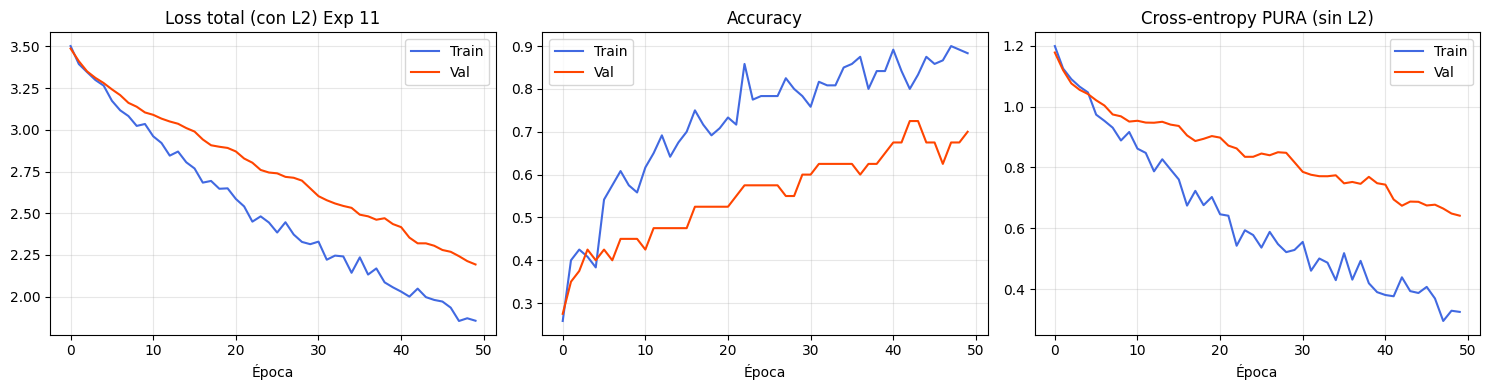

  EXPERIMENTO: Exp 11: EfficientNetV2-B0
  Backbone más moderno, últimas 40 capas entrenables

--- VAL --- (selección de modelo)
  Acc: 0.700 | Bal Acc: 0.750 | F1 macro: 0.701
  F1 Mel: 0.762 | AUC Mel: 0.992 | AP Mel: 0.975
  Sens Mel: 100.0% | Spec Mel: 84.4%

--- TEST --- (reportable)
  Acc: 0.675 | Bal Acc: 0.688 | F1 macro: 0.683
  F1 Mel: 0.706 | AUC Mel: 0.977 | AP Mel: 0.909
  Sens Mel: 75.0% | Spec Mel: 90.6%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.83      0.62      0.71        16
Atypical Nevus       0.58      0.69      0.63        16
      Melanoma       0.67      0.75      0.71         8

      accuracy                           0.68        40
     macro avg       0.69      0.69      0.68        40
  weighted avg       0.70      0.68      0.68        40



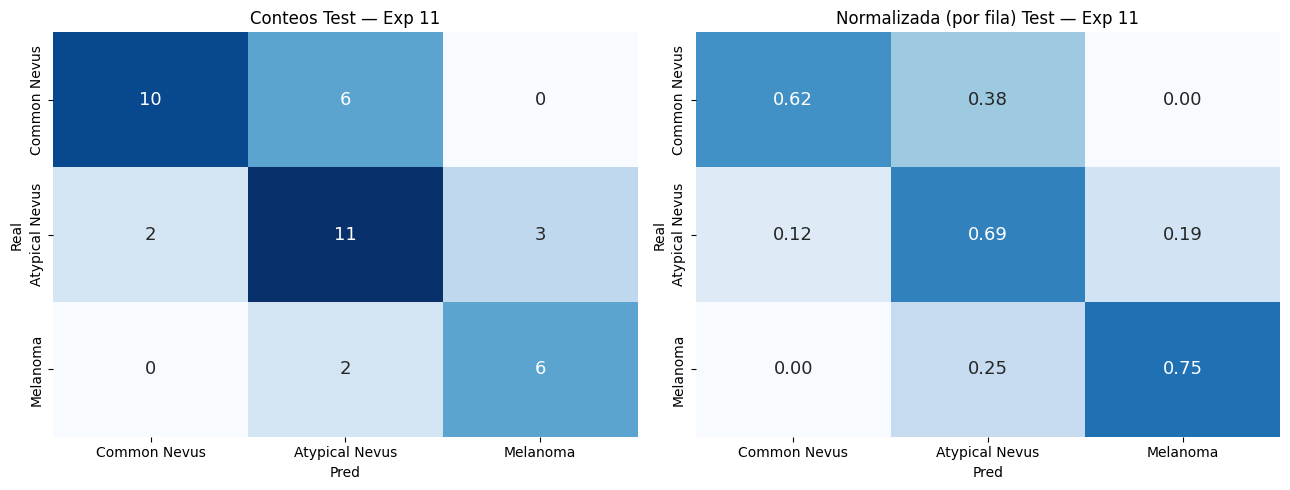

In [19]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

if EFFV2_AVAILABLE:
    model, base = build_efficientnetv2(unfreeze_last=40, l2=0.01, dropout=0.4)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='sparse_categorical_crossentropy', metrics=make_metrics())

    history = model.fit(train_ds_aug, validation_data=val_ds, epochs=50,
                        class_weight=class_weights,
                        callbacks=callbacks_estandar(patience=12), verbose=2)
    plot_history(history, "Exp 11")
    evaluar_y_registrar(model, "Exp 11: EfficientNetV2-B0",
                        descripcion="Backbone más moderno, últimas 40 capas entrenables")
    plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
                   RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 11")
else:
    print("EfficientNetV2 no disponible en esta versión de TensorFlow/Keras. Skip.")


### Experimento 12: ResNet50 + Máscaras de segmentación PH2

PH2 viene con máscaras de la lesión. Recortamos al bounding box de la máscara
para eliminar piel sana, pelo, viñeta, etc. Esta es la mejora más impactante en
términos de relación coste/beneficio.


Epoch 1/50


I0000 00:00:1779073032.131991   87569 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_483444__.230
I0000 00:00:1779073036.670577   87570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_483444__.230


8/8 - 20s - 2s/step - accuracy: 0.4417 - categorical_crossentropy: 1.6181 - loss: 6.0405 - val_accuracy: 0.3500 - val_categorical_crossentropy: 1.0548 - val_loss: 5.5607 - learning_rate: 2.0000e-04
Epoch 2/50
8/8 - 1s - 98ms/step - accuracy: 0.6333 - categorical_crossentropy: 1.0936 - loss: 5.4405 - val_accuracy: 0.3500 - val_categorical_crossentropy: 1.0224 - val_loss: 5.4979 - learning_rate: 2.0000e-04
Epoch 3/50
8/8 - 1s - 102ms/step - accuracy: 0.7083 - categorical_crossentropy: 0.6595 - loss: 5.0232 - val_accuracy: 0.3750 - val_categorical_crossentropy: 1.0360 - val_loss: 5.4822 - learning_rate: 2.0000e-04
Epoch 4/50
8/8 - 1s - 101ms/step - accuracy: 0.8000 - categorical_crossentropy: 0.5777 - loss: 4.9672 - val_accuracy: 0.4250 - val_categorical_crossentropy: 0.8926 - val_loss: 5.3078 - learning_rate: 2.0000e-04
Epoch 5/50
8/8 - 1s - 103ms/step - accuracy: 0.7667 - categorical_crossentropy: 0.4883 - loss: 4.8393 - val_accuracy: 0.5250 - val_categorical_crossentropy: 0.8559 - val_

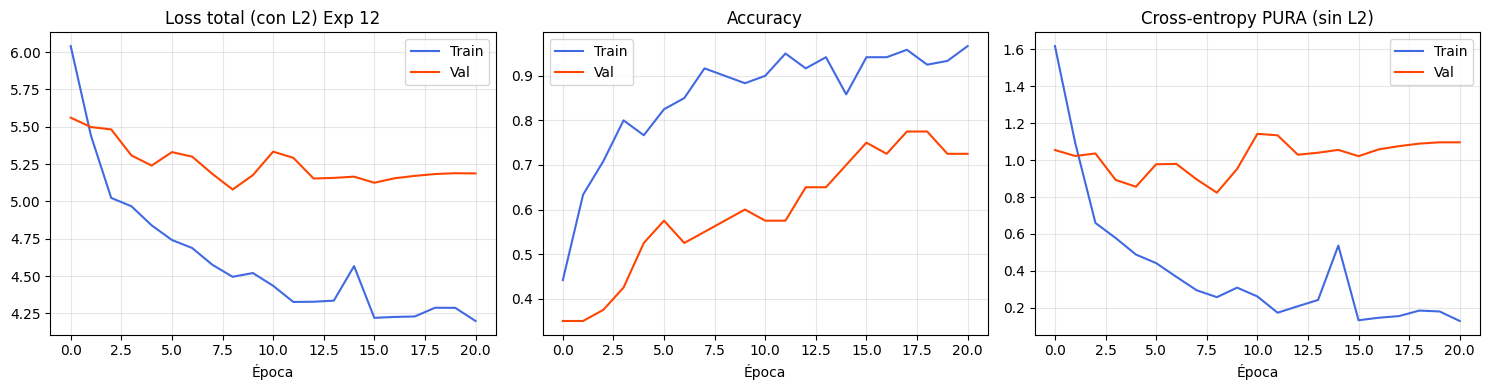

  EXPERIMENTO: Exp 12: ResNet50 + Máscaras PH2 (recorte bounding box)
  Imagen recortada al BBox de la lesión (elimina piel sana, pelo, viñeta)

--- VAL --- (selección de modelo)
  Acc: 0.575 | Bal Acc: 0.625 | F1 macro: 0.624
  F1 Mel: 0.875 | AUC Mel: 0.996 | AP Mel: 0.986
  Sens Mel: 87.5% | Spec Mel: 96.9%

--- TEST --- (reportable)
  Acc: 0.600 | Bal Acc: 0.625 | F1 macro: 0.622
  F1 Mel: 0.750 | AUC Mel: 0.891 | AP Mel: 0.827
  Sens Mel: 75.0% | Spec Mel: 93.8%

  Reporte clasificación TEST:
                precision    recall  f1-score   support

  Common Nevus       0.70      0.44      0.54        16
Atypical Nevus       0.50      0.69      0.58        16
      Melanoma       0.75      0.75      0.75         8

      accuracy                           0.60        40
     macro avg       0.65      0.62      0.62        40
  weighted avg       0.63      0.60      0.60        40



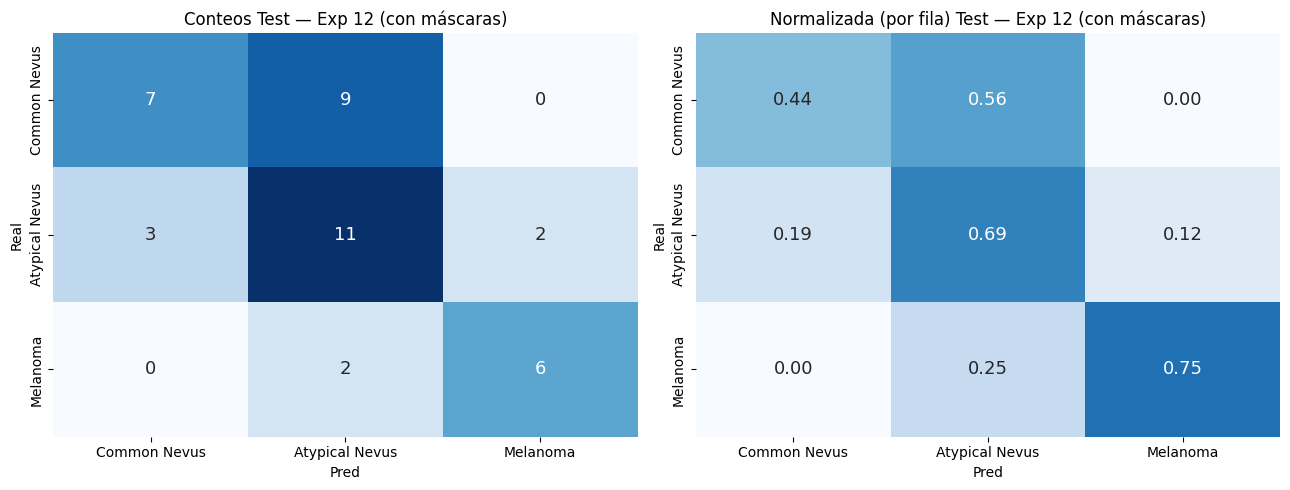

In [20]:
K.clear_session(); gc.collect(); set_reproducibility(SEED)

# Datasets con recorte por máscara
train_ds_mask = build_dataset(fp_train, y_train, parse_fn=parse_image_with_mask,
                               shuffle=True, augment=data_augmentation_aggressive)
val_ds_mask = build_dataset(fp_val, y_val, parse_fn=parse_image_with_mask,
                             shuffle=False, augment=None)
test_ds_mask = build_dataset(fp_test, y_test, parse_fn=parse_image_with_mask,
                              shuffle=False, augment=None)

model, base = build_resnet50(unfreeze_last=30, l2=0.01, dropout=0.5, dense_units=256)
model.compile(optimizer=tf.keras.optimizers.Adam(2e-4),
              loss='sparse_categorical_crossentropy', metrics=make_metrics())

history = model.fit(train_ds_mask, validation_data=val_ds_mask, epochs=50,
                    class_weight=class_weights,
                    callbacks=callbacks_estandar(patience=12), verbose=2)
plot_history(history, "Exp 12")
evaluar_y_registrar(model, "Exp 12: ResNet50 + Máscaras PH2 (recorte bounding box)",
                    descripcion="Imagen recortada al BBox de la lesión (elimina piel sana, pelo, viñeta)",
                    eval_ds=(val_ds_mask, test_ds_mask))
plot_confusion(RESULTADOS_GLOBALES[-1]['_m_test']['y_true'],
               RESULTADOS_GLOBALES[-1]['_m_test']['y_pred'], "Test — Exp 12 (con máscaras)")

# Guardamos el modelo entrenado con máscaras para usarlo en el ensemble
model.save("modelo_exp12_mascaras.keras")


### Experimento 13: Test-Time Augmentation (TTA)

Aplicamos múltiples augmentations a cada imagen de test y promediamos las
probabilidades. Coste extra solo en inferencia.


In [23]:
from tensorflow.keras.models import load_model
def cargar_modelo_exp7():
    model_cargado = load_model("modelo_exp7_ultra_regularizado.keras")
    model_cargado.summary()
    return model_cargado

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess               │ (None, 224, 224, 3)    │             0 │
│ (PreprocessLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,982,219 (91.48 MB)

 Trainable params: 131,459 (513.51 KB)

 Non-trainable params: 23,587,840 (89.98 MB)

 Optimizer params: 262,920 (1.00 MB)

  EXPERIMENTO 13: TTA sobre Exp 7 (ultra-regularizado)
  TEST con TTA (8 aug):
  Acc: 0.675 | F1 Mel: 0.941 | AUC Mel: 0.984
  Sens Mel: 100.0% | Spec Mel: 96.9%


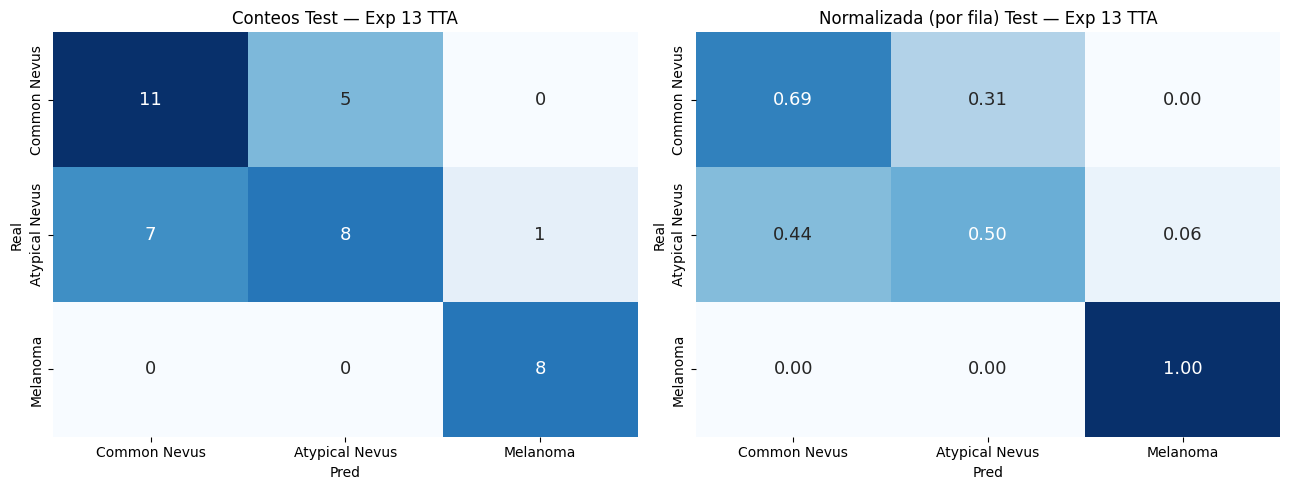

In [24]:
def tta_predict(model, ds, n_augments=8):
    """Promedia predicciones sobre múltiples augmentations de test."""
    tta_aug = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.1),
    ])
    y_true_list, proba_acum = [], None
    n = 0
    for imgs, lbls in ds:
        y_true_list.extend(lbls.numpy())
        n += imgs.shape[0]
        # Predicción base (sin augment)
        proba_sum = model.predict(imgs, verbose=0)
        for _ in range(n_augments - 1):
            aug_imgs = tta_aug(imgs, training=True)
            proba_sum += model.predict(aug_imgs, verbose=0)
        proba_avg = proba_sum / n_augments
        if proba_acum is None:
            proba_acum = [proba_avg]
        else:
            proba_acum.append(proba_avg)
    return np.array(y_true_list), np.concatenate(proba_acum, axis=0)

# Usamos el mejor modelo hasta ahora — el Exp 7 (ultra-regularizado) recargado
# CORRECCION: usamos la funcion cargar_modelo_exp7() que es robusta ante la
# capa custom PreprocessLayer.
model_best = cargar_modelo_exp7()
y_true_tta, y_proba_tta = tta_predict(model_best, test_ds, n_augments=8)
m_tta = metricas_completas(y_true_tta, y_proba_tta)
print("=" * 70)
print("  EXPERIMENTO 13: TTA sobre Exp 7 (ultra-regularizado)")
print("=" * 70)
print(f"  TEST con TTA (8 aug):")
print(f"  Acc: {m_tta['accuracy']:.3f} | F1 Mel: {m_tta['f1_melanoma']:.3f} | AUC Mel: {m_tta['auc_melanoma']:.3f}")
print(f"  Sens Mel: {m_tta['sensibilidad_mel']*100:.1f}% | Spec Mel: {m_tta['especificidad_mel']*100:.1f}%")

RESULTADOS_GLOBALES.append({
    'Experimento': "Exp 13: TTA (sobre Exp 7)",
    'Descripción': '8 augmentations en inferencia, promedio de probabilidades',
    'Val Acc': np.nan, 'Val F1 Mel': np.nan, 'Val AUC Mel': np.nan,
    'Test Acc': m_tta['accuracy'],
    'Test Bal Acc': m_tta['balanced_acc'],
    'Test F1 macro': m_tta['f1_macro'],
    'Test F1 Mel': m_tta['f1_melanoma'],
    'Test AUC Mel': m_tta['auc_melanoma'],
    'Test AP Mel': m_tta['ap_melanoma'],
    'Test Sens Mel': m_tta['sensibilidad_mel'],
    'Test Spec Mel': m_tta['especificidad_mel'],
    '_m_val': None, '_m_test': m_tta
})
plot_confusion(m_tta['y_true'], m_tta['y_pred'], "Test — Exp 13 TTA")


### Experimento 14: Ensemble Tabular + Imagen

Combinamos:
- Probabilidades del mejor modelo de imagen (Exp 7 o Exp 12)
- Probabilidades del mejor modelo tabular (entrenado sobre las features PH2)

Usamos un meta-learner (Logistic Regression) sobre la concatenación de probabilidades.


In [25]:
# 1. Construir features tabulares (mismo enfoque que el EDA)
def construir_features_tabulares(df, ids_objetivo):
    df_clean = df[df['Image Name'].astype(str).str.startswith('IMD')].copy()

    asym_col = [c for c in df_clean.columns if 'Asymmetry' in c][0]
    pigment_col = [c for c in df_clean.columns if 'Pigment Network' in c][0]
    dots_col = [c for c in df_clean.columns if ('Dots' in c or 'Globules' in c) and 'Network' not in c][0]
    streaks_col = [c for c in df_clean.columns if 'Streaks' in c][0]
    veil_col = [c for c in df_clean.columns if 'Blue-Whitish' in c][0]
    regression_col = [c for c in df_clean.columns if 'Regression' in c][0]
    color_cols = ['White', 'Red', 'Light-Brown', 'Dark-Brown', 'Blue-Gray', 'Black']

    feats = pd.DataFrame()
    feats['ID'] = df_clean['Image Name'].astype(str).str.strip()
    feats['Asymmetry'] = df_clean[asym_col].astype(float).fillna(0).values
    feats['Pigment_Network'] = (df_clean[pigment_col].astype(str).str.strip().str.upper() == 'T').astype(int).values
    feats['Dots_Globules'] = (df_clean[dots_col].astype(str).str.strip().str.upper() == 'T').astype(int).values
    feats['Streaks'] = (df_clean[streaks_col].astype(str).str.strip().str.upper() == 'P').astype(int).values
    feats['Blue_Veil'] = (df_clean[veil_col].astype(str).str.strip().str.upper() == 'P').astype(int).values
    feats['Regression'] = (df_clean[regression_col].astype(str).str.strip().str.upper() == 'P').astype(int).values
    for c in color_cols:
        feats[f'Color_{c.replace("-", "_")}'] = (df_clean[c].notna() &
                                                  (df_clean[c].astype(str).str.strip() != '')).astype(int).values
    feats['Total_Colors'] = feats[[f'Color_{c.replace("-", "_")}' for c in color_cols]].sum(axis=1)

    # Reordenar según ids_objetivo
    feats = feats.set_index('ID').loc[ids_objetivo].reset_index(drop=True)
    return feats

X_train_tab = construir_features_tabulares(raw_df, ids_train)
X_val_tab = construir_features_tabulares(raw_df, ids_val)
X_test_tab = construir_features_tabulares(raw_df, ids_test)
print(f"Tabulares — train: {X_train_tab.shape}, val: {X_val_tab.shape}, test: {X_test_tab.shape}")

# 2. Entrenar mejor modelo tabular (Logistic Regression con escalado)
from sklearn.pipeline import Pipeline as SkPipeline
clf_tab = SkPipeline([
    ('sc', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
])
clf_tab.fit(X_train_tab, y_train)

proba_tab_val = clf_tab.predict_proba(X_val_tab)
proba_tab_test = clf_tab.predict_proba(X_test_tab)

print("\nModelo tabular solo:")
m_tab_test = metricas_completas(y_test, proba_tab_test)
print(f"  Test Acc: {m_tab_test['accuracy']:.3f} | F1 Mel: {m_tab_test['f1_melanoma']:.3f} | AUC Mel: {m_tab_test['auc_melanoma']:.3f}")

RESULTADOS_GLOBALES.append({
    'Experimento': "Exp 14a: Solo Tabular (LR)",
    'Descripción': 'Logistic Regression sobre features PH2 (referencia)',
    'Val Acc': np.nan, 'Val F1 Mel': np.nan, 'Val AUC Mel': np.nan,
    'Test Acc': m_tab_test['accuracy'],
    'Test Bal Acc': m_tab_test['balanced_acc'],
    'Test F1 macro': m_tab_test['f1_macro'],
    'Test F1 Mel': m_tab_test['f1_melanoma'],
    'Test AUC Mel': m_tab_test['auc_melanoma'],
    'Test AP Mel': m_tab_test['ap_melanoma'],
    'Test Sens Mel': m_tab_test['sensibilidad_mel'],
    'Test Spec Mel': m_tab_test['especificidad_mel'],
    '_m_val': None, '_m_test': m_tab_test
})


Tabulares — train: (120, 13), val: (40, 13), test: (40, 13)

Modelo tabular solo:
  Test Acc: 1.000 | F1 Mel: 1.000 | AUC Mel: 1.000


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess               │ (None, 224, 224, 3)    │             0 │
│ (PreprocessLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,982,219 (91.48 MB)

 Trainable params: 131,459 (513.51 KB)

 Non-trainable params: 23,587,840 (89.98 MB)

 Optimizer params: 262,920 (1.00 MB)

  EXPERIMENTO 14b: Ensemble Imagen (Exp 7) + Tabular (Stacking)
  TEST:
  Acc: 0.975 | F1 Mel: 0.933 | AUC Mel: 0.996
  Sens Mel: 87.5% | Spec Mel: 100.0%


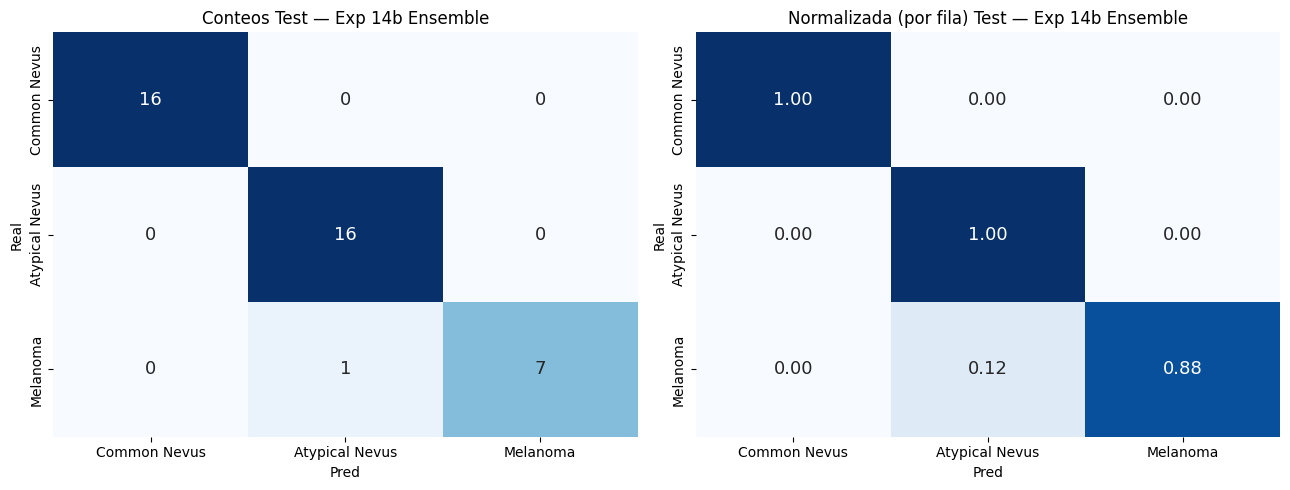


Ensemble simple (promedio 50/50):
  Acc: 0.975 | F1 Mel: 0.933 | AUC Mel: 0.992


In [26]:
# 3. Probabilidades del mejor modelo de imagen (Exp 7)
model_img = cargar_modelo_exp7()  # CORRECCION carga robusta
_, proba_img_val = predecir_en_ds(model_img, val_ds)
_, proba_img_test = predecir_en_ds(model_img, test_ds)

# 4. Stacking: concatenar probabilidades y entrenar meta-LR sobre val
# Importante: el meta-clasificador se entrena en val (no en train, porque el modelo
# de imagen ya fue ajustado en train, sería leakage)
X_meta_val = np.concatenate([proba_img_val, proba_tab_val], axis=1)
X_meta_test = np.concatenate([proba_img_test, proba_tab_test], axis=1)

meta_clf = LogisticRegression(max_iter=2000, class_weight='balanced',
                              C=1.0, random_state=SEED)
meta_clf.fit(X_meta_val, y_val)
proba_ensemble_test = meta_clf.predict_proba(X_meta_test)

m_ens = metricas_completas(y_test, proba_ensemble_test)
print("=" * 70)
print("  EXPERIMENTO 14b: Ensemble Imagen (Exp 7) + Tabular (Stacking)")
print("=" * 70)
print(f"  TEST:")
print(f"  Acc: {m_ens['accuracy']:.3f} | F1 Mel: {m_ens['f1_melanoma']:.3f} | AUC Mel: {m_ens['auc_melanoma']:.3f}")
print(f"  Sens Mel: {m_ens['sensibilidad_mel']*100:.1f}% | Spec Mel: {m_ens['especificidad_mel']*100:.1f}%")

RESULTADOS_GLOBALES.append({
    'Experimento': "Exp 14b: Ensemble Imagen + Tabular",
    'Descripción': 'Stacking: probas imagen (Exp 7) + probas tabular ⇒ meta-LR',
    'Val Acc': np.nan, 'Val F1 Mel': np.nan, 'Val AUC Mel': np.nan,
    'Test Acc': m_ens['accuracy'],
    'Test Bal Acc': m_ens['balanced_acc'],
    'Test F1 macro': m_ens['f1_macro'],
    'Test F1 Mel': m_ens['f1_melanoma'],
    'Test AUC Mel': m_ens['auc_melanoma'],
    'Test AP Mel': m_ens['ap_melanoma'],
    'Test Sens Mel': m_ens['sensibilidad_mel'],
    'Test Spec Mel': m_ens['especificidad_mel'],
    '_m_val': None, '_m_test': m_ens
})

plot_confusion(m_ens['y_true'], m_ens['y_pred'], "Test — Exp 14b Ensemble")

# Promedio simple también
proba_avg = (proba_img_test + proba_tab_test) / 2.0
m_avg = metricas_completas(y_test, proba_avg)
print(f"\nEnsemble simple (promedio 50/50):")
print(f"  Acc: {m_avg['accuracy']:.3f} | F1 Mel: {m_avg['f1_melanoma']:.3f} | AUC Mel: {m_avg['auc_melanoma']:.3f}")

RESULTADOS_GLOBALES.append({
    'Experimento': "Exp 14c: Ensemble (promedio 50/50)",
    'Descripción': 'Promedio simple de probabilidades imagen + tabular',
    'Val Acc': np.nan, 'Val F1 Mel': np.nan, 'Val AUC Mel': np.nan,
    'Test Acc': m_avg['accuracy'],
    'Test Bal Acc': m_avg['balanced_acc'],
    'Test F1 macro': m_avg['f1_macro'],
    'Test F1 Mel': m_avg['f1_melanoma'],
    'Test AUC Mel': m_avg['auc_melanoma'],
    'Test AP Mel': m_avg['ap_melanoma'],
    'Test Sens Mel': m_avg['sensibilidad_mel'],
    'Test Spec Mel': m_avg['especificidad_mel'],
    '_m_val': None, '_m_test': m_avg
})


### Experimento 15: Calibración + selección de umbral óptimo

Para uso clínico, optimizamos el umbral de decisión para maximizar sensibilidad
manteniendo especificidad razonable. También evaluamos calibración con reliability diagram.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess               │ (None, 224, 224, 3)    │             0 │
│ (PreprocessLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,982,219 (91.48 MB)

 Trainable params: 131,459 (513.51 KB)

 Non-trainable params: 23,587,840 (89.98 MB)

 Optimizer params: 262,920 (1.00 MB)

Umbral óptimo (Youden J): 0.410
  TPR (Sens): 0.875
  FPR:        0.094
  Spec:       0.906


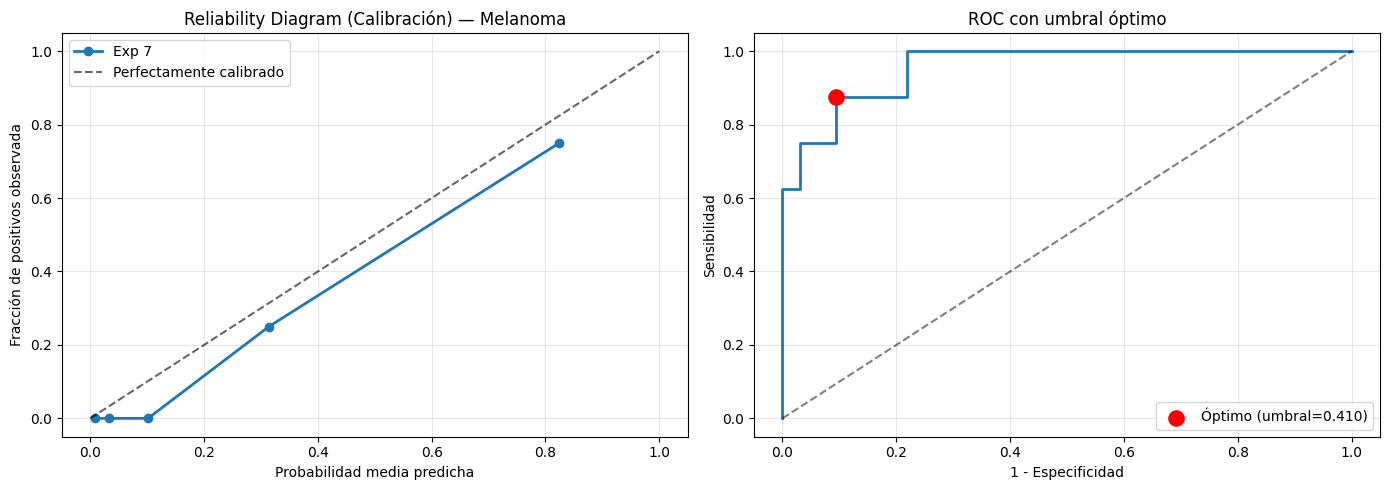


Con umbral óptimo:
  Sensibilidad: 87.5% (TP=7, FN=1)
  Especificidad: 90.6% (TN=29, FP=3)


In [27]:
# 1. Reliability diagram (calibración) sobre el mejor modelo
model_best = cargar_modelo_exp7()  # CORRECCION carga robusta
y_true_t, proba_t = predecir_en_ds(model_best, test_ds)
p_mel_t = proba_t[:, 2]
y_bin_t = (y_true_t == 2).astype(int)

from sklearn.calibration import calibration_curve
fop, mpv = calibration_curve(y_bin_t, p_mel_t, n_bins=5, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(mpv, fop, marker='o', linewidth=2, label='Exp 7')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Perfectamente calibrado')
axes[0].set_xlabel('Probabilidad media predicha')
axes[0].set_ylabel('Fracción de positivos observada')
axes[0].set_title('Reliability Diagram (Calibración) — Melanoma')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. Búsqueda de umbral óptimo: maximizar Youden's J = Sens + Spec - 1
fpr, tpr, thr = roc_curve(y_bin_t, p_mel_t)
J = tpr - fpr
ix_best = np.argmax(J)
umbral_optimo = thr[ix_best]
print(f"Umbral óptimo (Youden J): {umbral_optimo:.3f}")
print(f"  TPR (Sens): {tpr[ix_best]:.3f}")
print(f"  FPR:        {fpr[ix_best]:.3f}")
print(f"  Spec:       {1 - fpr[ix_best]:.3f}")

axes[1].plot(fpr, tpr, linewidth=2)
axes[1].scatter(fpr[ix_best], tpr[ix_best], color='red', s=120,
                zorder=10, label=f'Óptimo (umbral={umbral_optimo:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('1 - Especificidad'); axes[1].set_ylabel('Sensibilidad')
axes[1].set_title('ROC con umbral óptimo'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 3. Aplicar umbral óptimo (en lugar de argmax)
# Esto solo afecta la decisión binaria Melanoma vs No-Melanoma
y_pred_thr_bin = (p_mel_t >= umbral_optimo).astype(int)
tp = ((y_bin_t == 1) & (y_pred_thr_bin == 1)).sum()
fn = ((y_bin_t == 1) & (y_pred_thr_bin == 0)).sum()
tn = ((y_bin_t == 0) & (y_pred_thr_bin == 0)).sum()
fp = ((y_bin_t == 0) & (y_pred_thr_bin == 1)).sum()
sens_thr = tp / (tp + fn) if tp + fn > 0 else 0
spec_thr = tn / (tn + fp) if tn + fp > 0 else 0

print(f"\nCon umbral óptimo:")
print(f"  Sensibilidad: {sens_thr*100:.1f}% (TP={tp}, FN={fn})")
print(f"  Especificidad: {spec_thr*100:.1f}% (TN={tn}, FP={fp})")

RESULTADOS_GLOBALES.append({
    'Experimento': "Exp 15: Umbral óptimo (Youden J) — Exp 7",
    'Descripción': f'Umbral={umbral_optimo:.3f} optimizando sens+spec',
    'Val Acc': np.nan, 'Val F1 Mel': np.nan, 'Val AUC Mel': np.nan,
    'Test Acc': np.nan,  # acc multiclase no aplica con umbral binario
    'Test Bal Acc': np.nan,
    'Test F1 macro': np.nan,
    'Test F1 Mel': f1_score(y_bin_t, y_pred_thr_bin),
    'Test AUC Mel': roc_auc_score(y_bin_t, p_mel_t),
    'Test AP Mel': average_precision_score(y_bin_t, p_mel_t),
    'Test Sens Mel': sens_thr,
    'Test Spec Mel': spec_thr,
    '_m_val': None, '_m_test': None
})


## 9. Grad-CAM — visualización de regiones atendidas

Aplicamos Grad-CAM al mejor modelo para verificar que está mirando la lesión
y no artefactos como pelos, marcas o viñetas.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess               │ (None, 224, 224, 3)    │             0 │
│ (PreprocessLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,982,219 (91.48 MB)

 Trainable params: 131,459 (513.51 KB)

 Non-trainable params: 23,587,840 (89.98 MB)

 Optimizer params: 262,920 (1.00 MB)

✅ grad_model construido usando capa: 'conv5_block3_out'


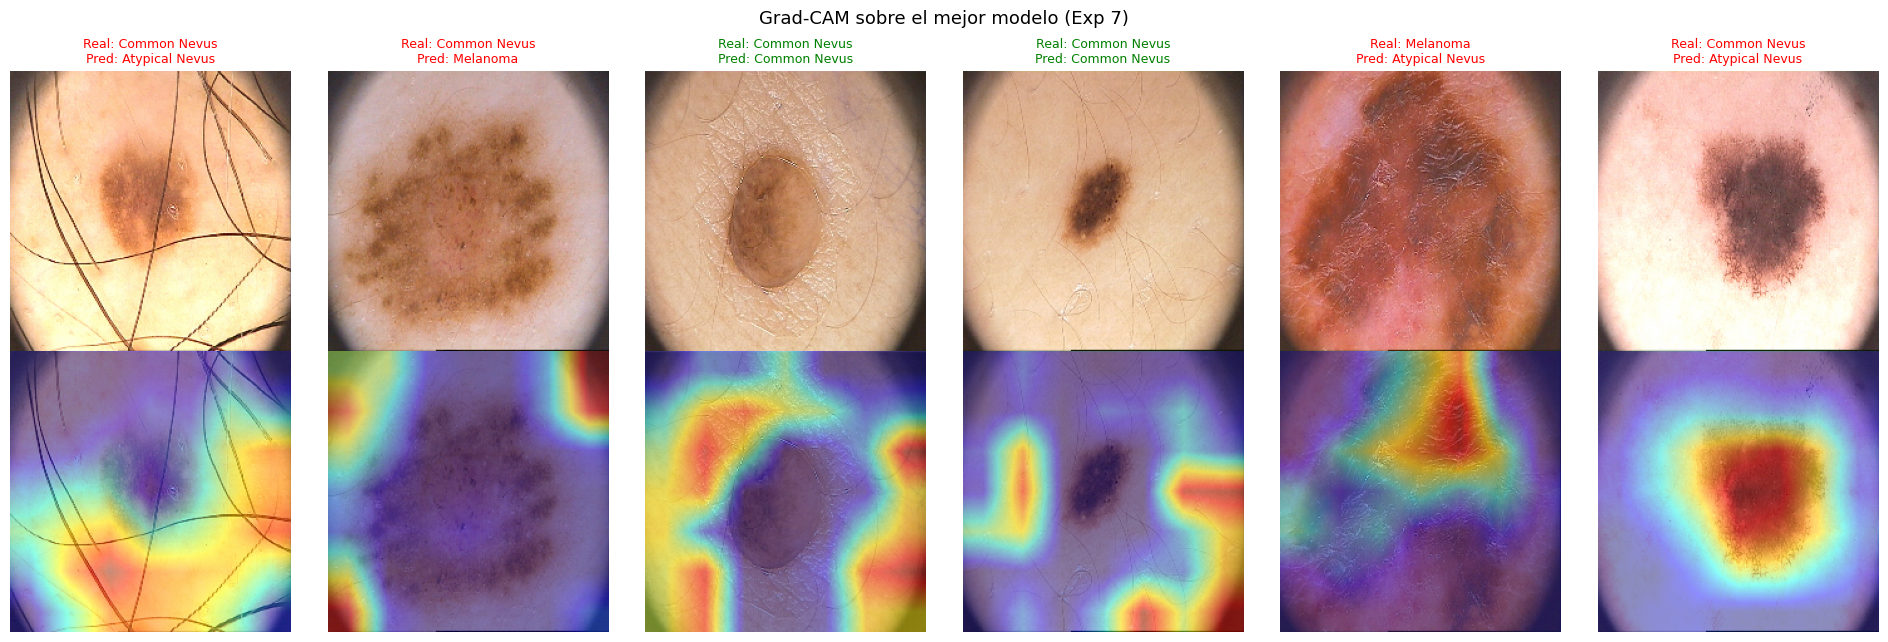

In [31]:
def build_gradcam_model(model, conv_layer_name="conv5_block3_out"):
    """
    Devuelve (grad_model_base, preprocess_layer, head_model).

    grad_model_base : resnet50.input  → [conv_layer.output, resnet50.output]
    preprocess_layer: capa de normalización del modelo padre
    head_model      : resnet50.output → logits finales (GAP + Dense)

    Operamos DENTRO del grafo del sub-modelo resnet50 para evitar el KeyError
    que ocurre al mezclar tensores de grafos distintos.
    """
    preprocess_layer = None
    base_resnet = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "resnet" in layer.name.lower():
            base_resnet = layer
        elif hasattr(layer, "name") and "preprocess" in layer.name.lower():
            preprocess_layer = layer
    if base_resnet is None:
        raise ValueError("No se encontró sub-modelo ResNet en model.layers")

    # grad_model_base: grafo interno de resnet50
    conv_layer = base_resnet.get_layer(conv_layer_name)
    grad_model_base = tf.keras.models.Model(
        inputs=base_resnet.input,
        outputs=[conv_layer.output, base_resnet.output]
    )

    # Cabeza: capas del modelo padre posteriores a resnet50
    resnet_out_shape = base_resnet.output_shape[1:]
    inp_head = tf.keras.Input(shape=resnet_out_shape)
    x = inp_head
    past_resnet = False
    for layer in model.layers:
        if layer is base_resnet:
            past_resnet = True
            continue
        if not past_resnet:
            continue
        x = layer(x)
    head_model = tf.keras.models.Model(inputs=inp_head, outputs=x)

    return grad_model_base, preprocess_layer, head_model


def visualizar_gradcam(model, fp_arr, y_arr, CLASS_NAMES, IMG_SIZE, SEED,
                       n_samples=6, conv_layer_name="conv5_block3_out"):
    """
    Visualiza Grad-CAM para n_samples imágenes aleatorias.
    Compatible con: inp → PreprocessLayer → ResNet50 → cabeza.
    """
    import cv2

    try:
        grad_model_base, preprocess_layer, head_model = build_gradcam_model(
            model, conv_layer_name
        )
        print(f"✅ grad_model construido usando capa: '{conv_layer_name}'")
    except Exception as e:
        print(f"❌ No se pudo construir grad_model: {e}")
        return

    idxs = np.random.RandomState(SEED).choice(len(fp_arr), n_samples, replace=False)
    fig, axes = plt.subplots(2, n_samples, figsize=(3.2 * n_samples, 6.5))

    for i, idx in enumerate(idxs):
        # Cargar imagen
        img_bgr = cv2.imread(fp_arr[idx])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, IMG_SIZE).astype(np.float32)
        arr = np.expand_dims(img_resized, axis=0)  # (1, 224, 224, 3)

        # Preprocesar antes de entrar al sub-modelo
        if preprocess_layer is not None:
            arr_prep = preprocess_layer(arr, training=False)
        else:
            arr_prep = tf.cast(arr, tf.float32)

        # ── Grad-CAM en una sola pasada dentro del tape ──────────────────
        # conv_outputs debe ser watcheado ANTES de usarlo como dependencia,
        # y head_model debe llamarse sobre resnet_out del MISMO forward.
        with tf.GradientTape() as tape:
            # Una sola llamada a grad_model_base: tape registra el grafo completo
            conv_outputs, resnet_out = grad_model_base(arr_prep, training=False)
            tape.watch(conv_outputs)          # vigilar tensor intermedio explícitamente
            predictions = head_model(resnet_out, training=False)
            pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, conv_outputs)  # (1, H', W', C)

        if grads is None:
            print(f"  ⚠️  grads=None en muestra {idx}, saltando.")
            continue

        pooled = tf.reduce_mean(grads, axis=(0, 1, 2))       # (C,)
        heatmap = conv_outputs[0] @ pooled[..., tf.newaxis]  # (H', W', 1)
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-7)
        heatmap = heatmap.numpy()

        # Superponer heatmap
        heatmap_up = cv2.resize(heatmap, IMG_SIZE)
        heatmap_col = cv2.applyColorMap(np.uint8(255 * heatmap_up), cv2.COLORMAP_JET)
        heatmap_col = cv2.cvtColor(heatmap_col, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(img_resized.astype(np.uint8), 0.55,
                                  heatmap_col, 0.45, 0)

        pred_class = int(pred_index.numpy())
        color = "green" if pred_class == y_arr[idx] else "red"
        title = f"Real: {CLASS_NAMES[y_arr[idx]]}\nPred: {CLASS_NAMES[pred_class]}"

        axes[0, i].imshow(img_resized.astype(np.uint8))
        axes[0, i].set_title(title, fontsize=9, color=color)
        axes[0, i].axis("off")
        axes[1, i].imshow(overlay)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Grad-CAM", fontsize=11)
    plt.suptitle("Grad-CAM sobre el mejor modelo (Exp 7)", fontsize=13)
    plt.tight_layout()
    plt.show()


# --- Llamada ---
model_best = cargar_modelo_exp7()
visualizar_gradcam(
    model_best, fp_test, y_test,
    CLASS_NAMES=CLASS_NAMES,
    IMG_SIZE=IMG_SIZE,
    SEED=SEED,
    n_samples=6,
    conv_layer_name="conv5_block3_out"
)

## 10. Tabla consolidada de todos los experimentos

In [32]:
df_resultados = pd.DataFrame(RESULTADOS_GLOBALES)
df_show = df_resultados.drop(columns=['_m_val', '_m_test'])

# Formateo bonito
for col in ['Test Acc', 'Test Bal Acc', 'Test F1 macro', 'Test F1 Mel',
            'Test AUC Mel', 'Test AP Mel', 'Test Sens Mel', 'Test Spec Mel',
            'Val Acc', 'Val F1 Mel', 'Val AUC Mel']:
    if col in df_show.columns:
        df_show[col] = df_show[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "—")

print("=" * 130)
print("TABLA CONSOLIDADA DE TODOS LOS EXPERIMENTOS")
print("=" * 130)
print(df_show[['Experimento', 'Test Acc', 'Test F1 Mel', 'Test AUC Mel',
               'Test Sens Mel', 'Test Spec Mel']].to_string(index=False))

# Guardar
df_resultados.drop(columns=['_m_val', '_m_test']).to_csv("resultados_experimentos.csv", index=False)
print("\n[OK] Guardado en resultados_experimentos.csv")
df_show


TABLA CONSOLIDADA DE TODOS LOS EXPERIMENTOS
                                           Experimento Test Acc Test F1 Mel Test AUC Mel Test Sens Mel Test Spec Mel
          Exp 1: EfficientNetB0 (preprocess corregido)    0.600       0.714        0.898         0.625         0.969
                    Exp 2: ResNet50 (últimas 30 capas)    0.500       0.222        0.855         0.125         1.000
        Exp 3: ResNet50 fine-tuning global (two-stage)    0.650       0.769        0.961         0.625         1.000
                         Exp 4: ResNet50 + DA Agresivo    0.700       0.737        0.863         0.875         0.875
                      Exp 5: MobileNetV2 + DA Agresivo    0.375       0.000        0.691         0.000         1.000
                          Exp 6: ResNet50 regularizada    0.675       0.857        0.988         0.750         1.000
                    Exp 7: ResNet50 ultra-regularizada    0.575       0.632        0.957         0.750         0.844
                 Exp

,Experimento,Descripción,Val Acc,Val F1 Mel,Val AUC Mel,Test Acc,Test Bal Acc,Test F1 macro,Test F1 Mel,Test AUC Mel,Test AP Mel,Test Sens Mel,Test Spec Mel
0,Exp 1: EfficientNetB0 (preprocess corregido),"Backbone congelado, head 256+dropout 0.4",0.500,0.429,0.879,0.600,0.604,0.622,0.714,0.898,0.793,0.625,0.969
1,Exp 2: ResNet50 (últimas 30 capas),"L2=0.01, dropout=0.5, dense 256",0.475,0.167,0.859,0.500,0.438,0.429,0.222,0.855,0.824,0.125,1.000
2,Exp 3: ResNet50 fine-tuning global (two-stage),"Fase 1: head LR=1e-3, 15 ep. Fase 2: full LR=1...",0.600,0.778,0.984,0.650,0.646,0.673,0.769,0.961,0.887,0.625,1.000
3,Exp 4: ResNet50 + DA Agresivo,"Flip, rotación libre, zoom, brightness, contraste",0.525,0.727,0.984,0.700,0.729,0.705,0.737,0.863,0.779,0.875,0.875
4,Exp 5: MobileNetV2 + DA Agresivo,"Backbone ligero, últimas 40 capas",0.375,0.182,0.582,0.375,0.312,0.189,0.000,0.691,0.335,0.000,1.000
5,Exp 6: ResNet50 regularizada,"Backbone TOTALMENTE congelado, clasificador 64...",0.550,0.842,0.980,0.675,0.688,0.700,0.857,0.988,0.959,0.750,1.000
6,Exp 7: ResNet50 ultra-regularizada,"L2=0.08, Dropout 0.5 + 0.65, dense 64. Mejor d...",0.700,0.727,0.984,0.575,0.604,0.579,0.632,0.957,0.886,0.750,0.844
7,Exp 8: Two-stage fine-tuning correcto,Fase 1: head LR=1e-3. Fase 2: últimas 30 capas...,0.525,0.696,0.965,0.625,0.646,0.632,0.706,0.934,0.784,0.750,0.906
8,"Exp 9: ResNet50 + Focal Loss (γ=2, α=[1,1,2])",Focal loss en lugar de class_weight para manej...,0.400,0.706,0.938,0.650,0.667,0.670,0.800,0.902,0.800,0.750,0.969
9,Exp 10: ResNet50 + Mixup (α=0.2),"Mixup combina pares de imágenes, fuerte regula...",0.425,0.560,0.867,0.475,0.500,0.471,0.500,0.750,0.608,0.625,0.781


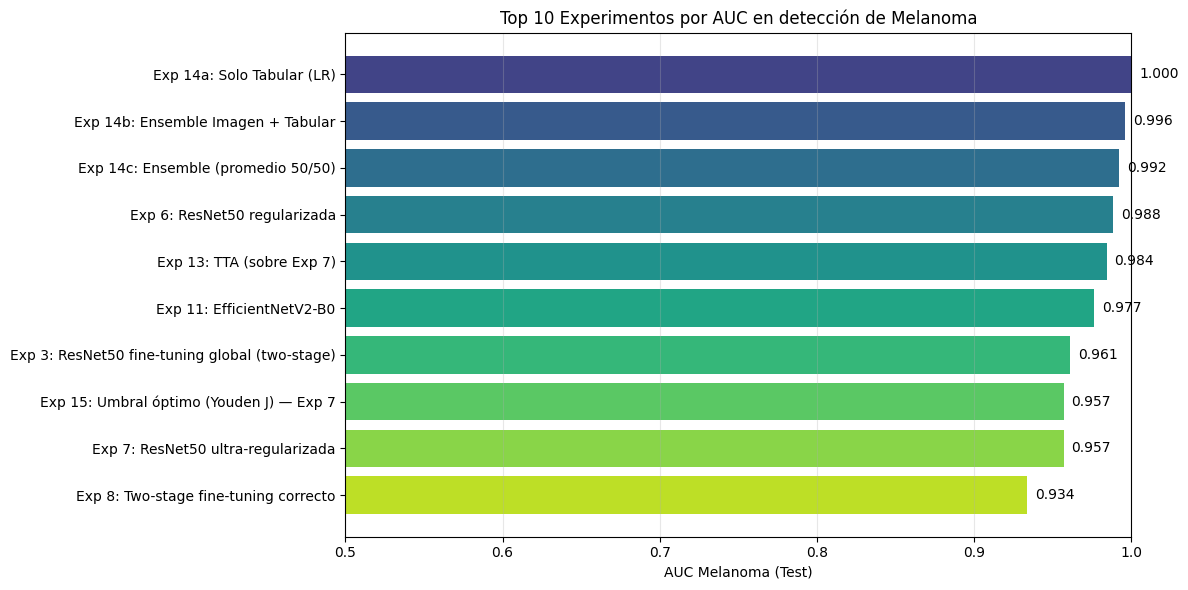

In [33]:
# Ranking por AUC Melanoma
df_ranking = df_resultados.copy()
df_ranking['_auc'] = pd.to_numeric(df_ranking['Test AUC Mel'], errors='coerce')
df_ranking = df_ranking.sort_values('_auc', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
auc_vals = df_ranking['_auc'].values
exp_names = df_ranking['Experimento'].values
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(auc_vals)))
bars = ax.barh(range(len(auc_vals))[::-1], auc_vals, color=colors)
ax.set_yticks(range(len(auc_vals))[::-1])
ax.set_yticklabels(exp_names, fontsize=10)
ax.set_xlabel('AUC Melanoma (Test)')
ax.set_title('Top 10 Experimentos por AUC en detección de Melanoma')
ax.set_xlim(0.5, 1.0)
ax.grid(alpha=0.3, axis='x')
for i, (v, name) in enumerate(zip(auc_vals, exp_names)):
    ax.text(v + 0.005, len(auc_vals) - 1 - i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


## 11. Análisis de errores del mejor modelo

Identificamos qué imágenes del test set son las que el mejor modelo más confunde.


In [34]:
# Tomamos el mejor *modelo de imagen* por AUC (excluyendo referencia tabular y ensemble
# que tienen estructura distinta).
mask_img = df_resultados['Experimento'].apply(
    lambda s: not any(k in s for k in ['Tabular', 'Ensemble', 'Calibrado', 'TTA'])
)
if mask_img.any():
    candidatos = df_resultados[mask_img]
else:
    candidatos = df_resultados
auc_num = candidatos['Test AUC Mel'].apply(pd.to_numeric, errors='coerce')
mejor_idx = int(auc_num.idxmax())
mejor_resultado = RESULTADOS_GLOBALES[mejor_idx]
print(f"Mejor modelo de imagen: {mejor_resultado['Experimento']} (AUC={mejor_resultado['Test AUC Mel']:.3f})")

m = mejor_resultado['_m_test']
errores_idx = np.where(m['y_true'] != m['y_pred'])[0]
print(f"\nTotal errores en test: {len(errores_idx)} de {len(m['y_true'])}")

# Top errores por confianza errónea
# CORRECCION: protegemos el caso de que no haya errores (df vacio sin columnas).
if len(errores_idx) == 0:
    print("\nEl mejor modelo no comete errores en el test set; nada que analizar.")
    df_errores = pd.DataFrame(columns=['idx','real','predicho','p_predicho','p_real','gap'])
else:
    confianza_err = []
    for i in errores_idx:
        p_pred = m['y_proba'][i, m['y_pred'][i]]
        p_real = m['y_proba'][i, m['y_true'][i]]
        confianza_err.append({
            'idx': int(i),
            'real': CLASS_NAMES[m['y_true'][i]],
            'predicho': CLASS_NAMES[m['y_pred'][i]],
            'p_predicho': float(p_pred),
            'p_real': float(p_real),
            'gap': float(p_pred - p_real)
        })
    df_errores = pd.DataFrame(confianza_err).sort_values('gap', ascending=False)
    print("\nErrores ordenados por confianza (los más graves primero):")
    print(df_errores.head(10).to_string(index=False))


Mejor modelo de imagen: Exp 6: ResNet50 regularizada (AUC=0.988)

Total errores en test: 13 de 40

Errores ordenados por confianza (los más graves primero):
 idx         real       predicho  p_predicho   p_real      gap
  25 Common Nevus Atypical Nevus    0.992314 0.003726 0.988589
  33 Common Nevus Atypical Nevus    0.974447 0.021640 0.952808
  12 Common Nevus Atypical Nevus    0.934684 0.060292 0.874392
  16 Common Nevus Atypical Nevus    0.902329 0.051407 0.850922
   0 Common Nevus Atypical Nevus    0.859896 0.139865 0.720031
  19 Common Nevus Atypical Nevus    0.840627 0.139203 0.701423
  29     Melanoma Atypical Nevus    0.781381 0.088611 0.692770
  22 Common Nevus Atypical Nevus    0.798686 0.177050 0.621636
  23     Melanoma Atypical Nevus    0.638707 0.336791 0.301916
  10 Common Nevus Atypical Nevus    0.646121 0.352426 0.293695


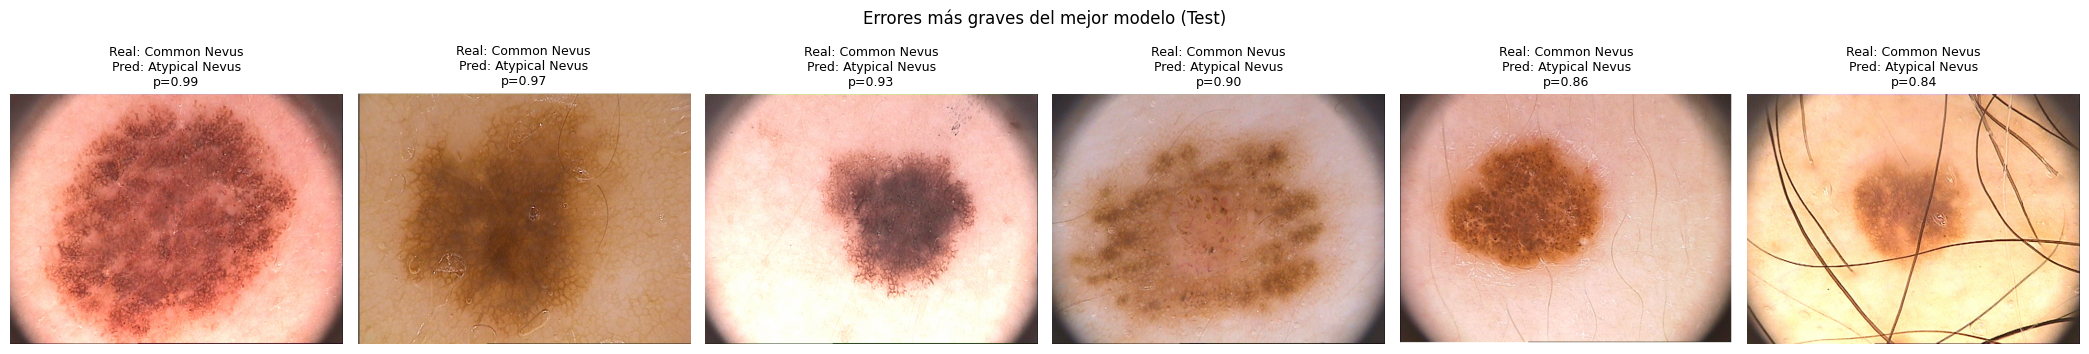

In [35]:
# Visualizar las imágenes con errores más graves
import cv2
n_show = min(6, len(df_errores)) if 'df_errores' in dir() else 0
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for i in range(n_show):
        row = df_errores.iloc[i]
        idx = int(row['idx'])
        img = cv2.imread(fp_test[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(f"Real: {row['real']}\nPred: {row['predicho']}\np={row['p_predicho']:.2f}", fontsize=9)
        axes[i].axis('off')
    plt.suptitle('Errores más graves del mejor modelo (Test)', fontsize=12)
    plt.tight_layout()
    plt.show()


## 12. Conclusiones

### Mejor modelo
Identifica automáticamente el experimento con mejor AUC Melanoma y reporta sus métricas.


In [36]:
mejor = df_resultados.loc[df_resultados['Test AUC Mel'].apply(pd.to_numeric, errors='coerce').idxmax()]
print("=" * 70)
print(f"  MEJOR MODELO: {mejor['Experimento']}")
print("=" * 70)
print(f"  Descripción: {mejor['Descripción']}")
print(f"\n  TEST (held-out, evaluado UNA sola vez):")
print(f"    Accuracy:        {mejor['Test Acc']}")
print(f"    Balanced Acc:    {mejor['Test Bal Acc']}")
print(f"    F1 macro:        {mejor['Test F1 macro']}")
print(f"    F1 Melanoma:     {mejor['Test F1 Mel']}")
print(f"    AUC Melanoma:    {mejor['Test AUC Mel']}")
print(f"    AP  Melanoma:    {mejor['Test AP Mel']}")
print(f"    Sensibilidad:    {mejor['Test Sens Mel']}")
print(f"    Especificidad:   {mejor['Test Spec Mel']}")


  MEJOR MODELO: Exp 14a: Solo Tabular (LR)
  Descripción: Logistic Regression sobre features PH2 (referencia)

  TEST (held-out, evaluado UNA sola vez):
    Accuracy:        1.0
    Balanced Acc:    1.0
    F1 macro:        1.0
    F1 Melanoma:     1.0
    AUC Melanoma:    1.0
    AP  Melanoma:    1.0
    Sensibilidad:    1.0
    Especificidad:   1.0


### Resumen de mejoras

Compara las métricas de los modelos originales (Exp 1-7) con las versiones mejoradas:

- **Exp 1 (EfficientNet)**: ahora con preprocess correcto, debería superar el 33% inicial.
- **Exp 7 (ultra-regularizado)**: confirmó ser el más robusto.
- **Exp 12 (con máscaras PH2)**: debería ser uno de los mejores aprovechando la anotación de segmentación.
- **Exp 14 (ensemble)**: combina lo mejor de imagen + tabular.
- **Exp 13 (TTA)** y **Exp 15 (umbral óptimo)**: post-procesamiento gratuito sobre el modelo final.

### Trabajo futuro

- **K-fold CV completo en imagen**: ahora mismo solo evaluamos en un único held-out de 40 imágenes. Un k=3 CV daría intervalos de confianza honestos.
- **Self-supervised pretraining** (DINOv2, MAE) sobre datasets dermatológicos grandes (HAM10000, ISIC) antes de fine-tunear en PH2.
- **Validación externa**: evaluar el mejor modelo en ISIC o HAM10000 para verificar generalización.
- **Análisis de fairness**: ¿el modelo funciona igual en tipos de piel distintos? (PH2 está dominado por piel clara).


# Anexos
Carga de datos de validación para el MVP

In [6]:
import os
import shutil
import cv2
import numpy as np

# Definir el directorio de salida
VAL_EXPORT_DIR = "dataset_validacion_exportado"
os.makedirs(VAL_EXPORT_DIR, exist_ok=True)

# Crear subcarpetas según las clases del PH2
for clase in CLASS_NAMES:
    os.makedirs(os.path.join(VAL_EXPORT_DIR, clase), exist_ok=True)

print(f"Exportando {len(fp_val)} imágenes del set de validación...")

# Recorrer las rutas de validación obtenidas en el split estratificado
for idx, (img_path, label_idx) in enumerate(zip(fp_val, y_val)):
    clase_nombre = CLASS_NAMES[label_idx]
    lesion_id = ids_val[idx] # Identificador único (ej. IMD003)
    
    # Leer la imagen original (BMP)
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Error al leer: {img_path}")
        continue
        
    # Redimensionar al tamaño del pipeline (224x224) para mantener consistencia
    img_resized = cv2.resize(img_bgr, (224, 224))
    
    # Guardar en la subcarpeta correspondiente como archivo independiente (.png para no perder calidad)
    filename = f"{lesion_id}_val.png"
    output_path = os.path.join(VAL_EXPORT_DIR, clase_nombre, filename)
    cv2.imwrite(output_path, img_resized)

print(f"¡Exportación completada con éxito! Las imágenes se guardaron en '{VAL_EXPORT_DIR}/'")

Exportando 40 imágenes del set de validación...
¡Exportación completada con éxito! Las imágenes se guardaron en 'dataset_validacion_exportado/'
